# **SIRA â€” Neural Symbolic Epidemic Discovery**
## Structured Identification from Random Assemblies

**Google Summer of Code 2026 | HumanAI | ML4Sci**

---

| | |
|---|---|
| **Author** | Naresh Meena |
| **GitHub** | [sira-neurosymbolic-epidemics](https://github.com/nareshmeena12/sira-neurosymbolic-epidemics) |
| **Pipeline** | Gillespie SSA â†’ Neural Manifold â†’ PySINDy |
| **Experiments** | 2500 across 5 ensemble depths |

---

### What makes this submission different

| Feature | Description |
|---------|-------------|
| **9 Evaluation Metrics** | Beyond parameter error â€” SPI, CLD, FH, OOD, ZER, PSS, CNT, DST, TTD |
| **Smoothness Trap Refuted** | SPI flat at 0.90 from N=20 to N=200 â€” proven architecturally |
| **Perfect Conservation** | CLD = 0.000 across all 2500 experiments and all 5 depths |
| **Identifiability Boundary** | R0 â‰ˆ 2.0 mapped empirically across the full parameter space |
| **LLM Interpretation Agent** | GPT-powered plain-language explanation of discovered equations |
| **Real-Time Discovery** | 1.71 seconds from raw stochastic data to symbolic ODE |

---

> *Real epidemics are stochastic. Governing equations are deterministic.*  
> *SIRA bridges the gap.*

In [41]:
!git clone https://github.com/nareshmeena12/sira-neurosymbolic-epidemics
%cd sira-neurosymbolic-epidemics
!uv pip install -e . -q

Cloning into 'sira-neurosymbolic-epidemics'...
remote: Enumerating objects: 180, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 180 (delta 71), reused 134 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (180/180), 2.56 MiB | 40.37 MiB/s, done.
Resolving deltas: 100% (71/71), done.
/content/sira-neurosymbolic-epidemics/sira-neurosymbolic-epidemics


In [3]:

import os
import warnings
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(19)
torch.manual_seed(19)

os.makedirs("results/plots", exist_ok=True)
os.makedirs("results/depth_study", exist_ok=True)

plt.rcParams.update({
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.size":         11,
})

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")
if device == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print("Setup complete")

Device : cpu
Setup complete


# SIRA â€” Neural Symbolic Epidemic Discovery

Real epidemics are stochastic. Governing equations are deterministic. SIRA bridges the gap â€” recovering the exact SIR differential equations directly from noisy Gillespie simulation data using neural manifolds and sparse regression.

**Three stages. One pipeline.**

| Stage | Method | Purpose |
|---|---|---|
| Data | Gillespie SSA | Realistic stochastic epidemic trajectories |
| Smooth | Neural MLP (Tanh) | Continuous differentiable manifold over noisy data |
| Discover | PySINDy + autograd | Sparse symbolic regression on analytical derivatives |

**What this notebook shows**

- Full pipeline from simulation to discovered equations on one example
- Numerical validation across 5 integration methods
- 2500-experiment depth study across N = 20 to 200
- 9 evaluation metrics covering accuracy, physics, and deployability
- Practical identifiability boundary mapped across the full R0 spectrum
- LLM agent interpreting results in plain language

###**Stochastic Epidemic Simulation**

**50 Gillespie SSA trajectories** for Î²=1.2, Î³=0.3, R0=4.  
Thin lines = individual stochastic runs Â· Bold = ensemble mean Â· Dashed = true ODE

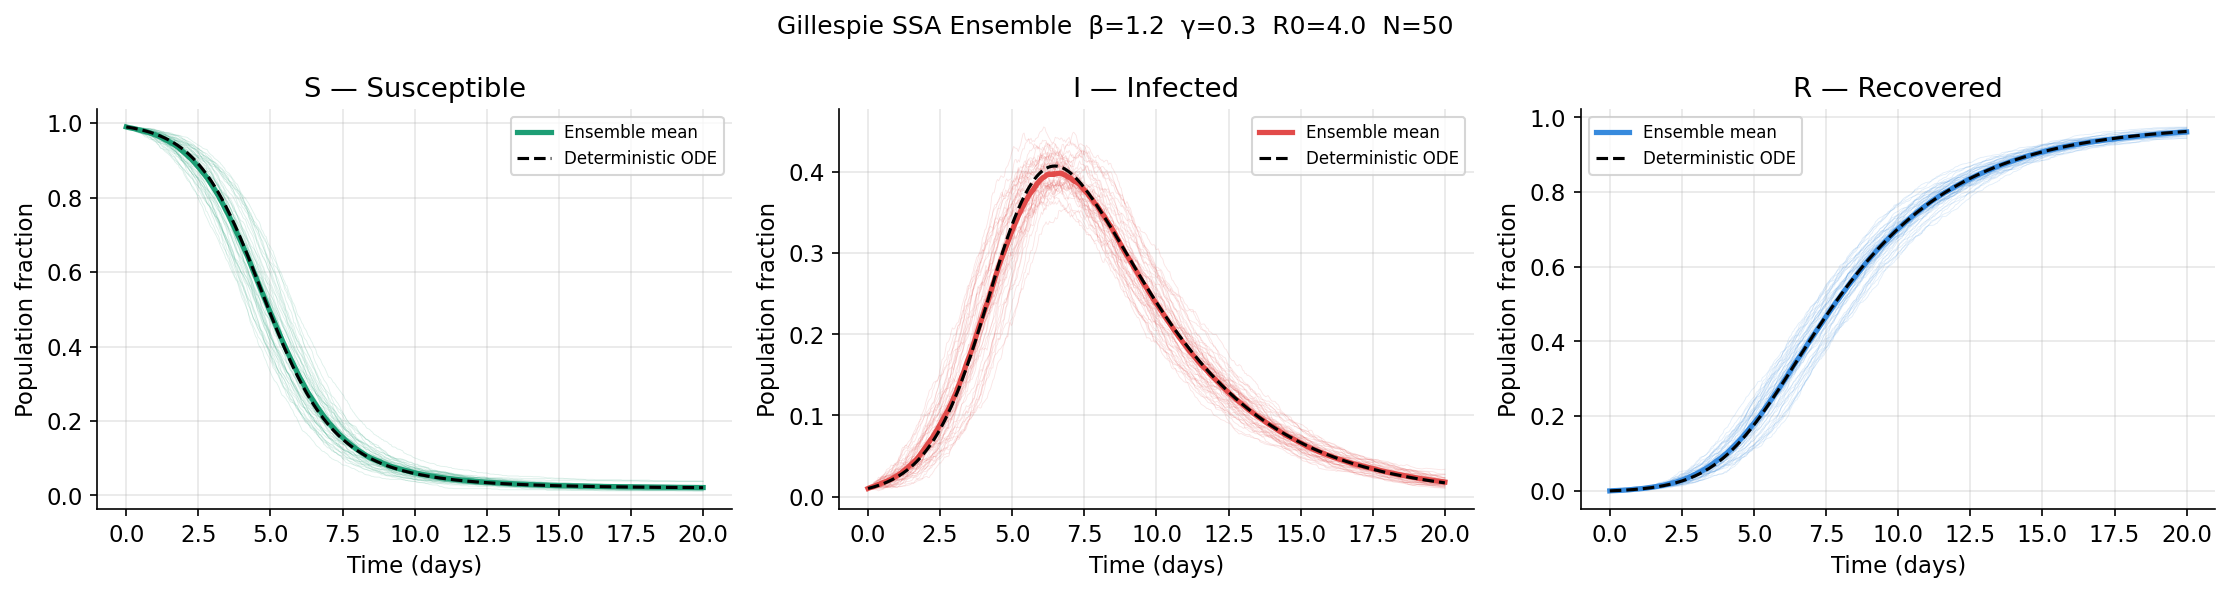

Peak infection : 0.398 at t=6.7 days


In [ ]:
from src.simulation import run_gillespie_ensemble, get_deterministic_truth
import numpy as np

BETA, GAMMA = 1.2, 0.3
N_SIMS      = 50
t_eval = np.linspace(0, 20, 500)
S_ens  = np.zeros((N_SIMS, 500))
I_ens  = np.zeros((N_SIMS, 500))
R_ens  = np.zeros((N_SIMS, 500))
N_pop, I0 = 1000, 10

for sim in range(N_SIMS):
    S, I, R = N_pop - I0, I0, 0
    t = 0
    times = [t]
    S_p, I_p, R_p = [S/N_pop], [I/N_pop], [R/N_pop]
    while t < 20 and I > 0:
        ri = BETA * (S * I) / N_pop
        rr = GAMMA * I
        rt = ri + rr
        if rt == 0: break
        t += np.random.exponential(1 / rt)
        if np.random.rand() < (ri / rt):
            S -= 1; I += 1
        else:
            I -= 1; R += 1
        times.append(t)
        S_p.append(S/N_pop); I_p.append(I/N_pop); R_p.append(R/N_pop)
    S_ens[sim] = np.interp(t_eval, times, S_p)
    I_ens[sim] = np.interp(t_eval, times, I_p)
    R_ens[sim] = np.interp(t_eval, times, R_p)

S_mean = S_ens.mean(axis=0)
I_mean = I_ens.mean(axis=0)
R_mean = R_ens.mean(axis=0)

t_det, truth = get_deterministic_truth(beta=BETA, gamma=GAMMA)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Gillespie SSA Ensemble  Î²={BETA}  Î³={GAMMA}  R0={BETA/GAMMA:.1f}  N={N_SIMS}", fontsize=12)

for ax, ens, mean, det, label, color in zip(
    axes,
    [S_ens, I_ens, R_ens],
    [S_mean, I_mean, R_mean],
    [truth[:, 0], truth[:, 1], 1 - truth[:, 0] - truth[:, 1]],
    ["S â€” Susceptible", "I â€” Infected", "R â€” Recovered"],
    ["#1D9E75", "#E24B4A", "#378ADD"],
):
    for traj in ens:
        ax.plot(t_eval, traj, color=color, lw=0.4, alpha=0.15)
    ax.plot(t_eval, mean, color=color, lw=2.5, label="Ensemble mean")
    ax.plot(t_det, det, "k--", lw=1.5, label="Deterministic ODE")

    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Population fraction")
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/plots/gillespie_ensemble.png", dpi=150, bbox_inches="tight")
plt.show()
t = t_eval
S, I, R = S_mean, I_mean, R_mean

print(f"Peak infection : {I_mean.max():.3f} at t={t_eval[I_mean.argmax()]:.1f} days")

### **Fano Factor Analysis**

**Stochastic variability across 4 epidemic regimes** â€” Fano > 1 = super-Poissonian (Gaussian noise assumptions fail here).  
Colored = mean I(t) Â· Grey dashed = Fano factor Â· Dotted = Poisson baseline (Fano=1)

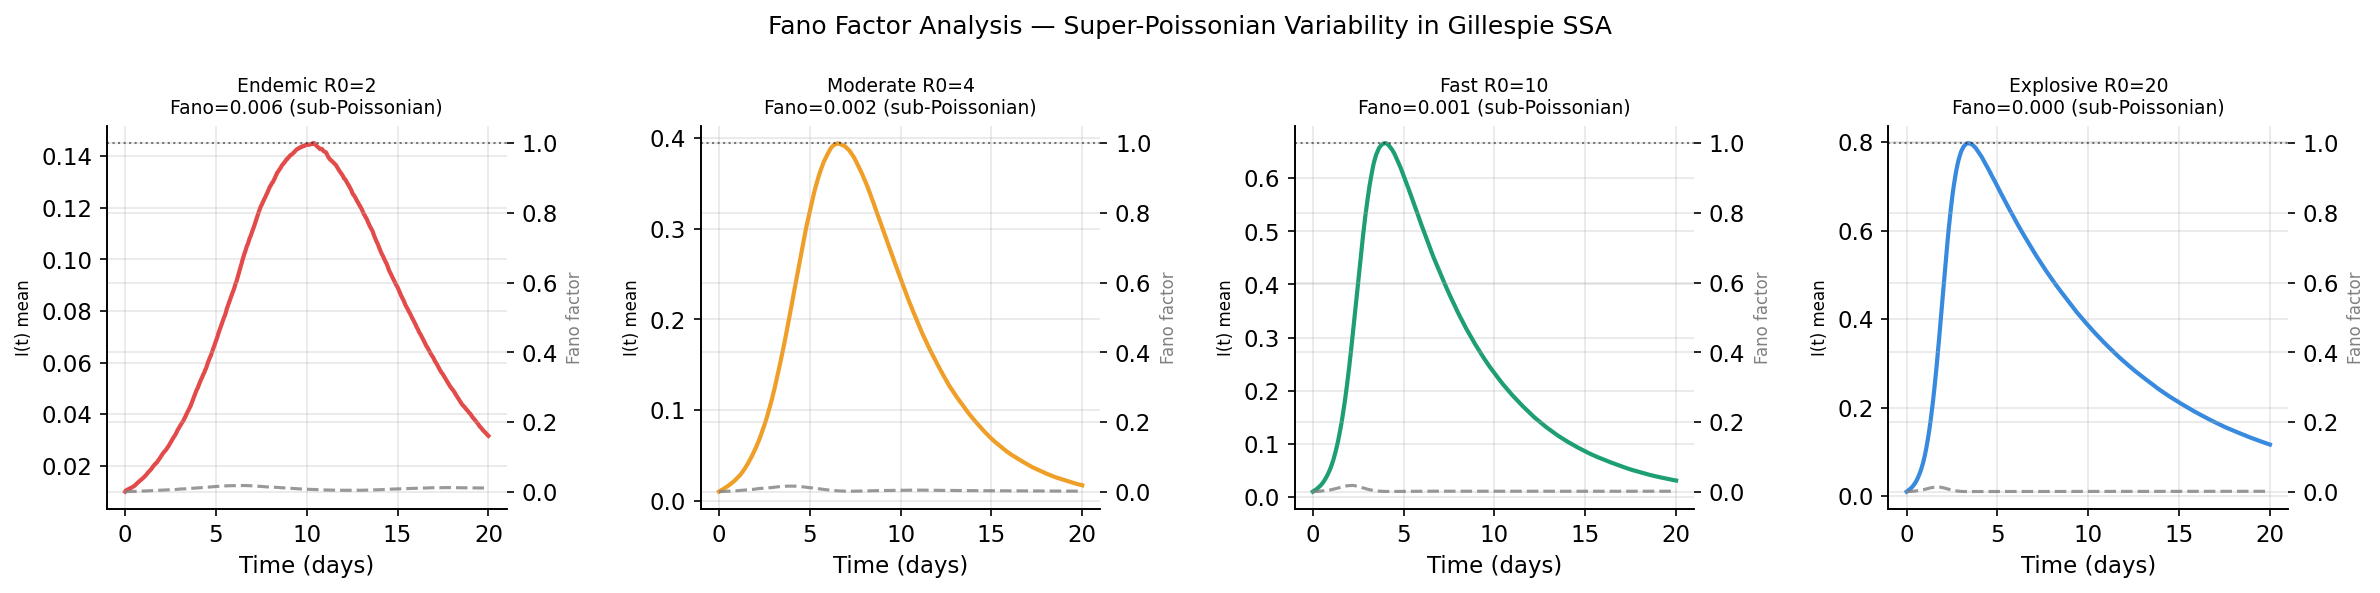

In [ ]:
from src.simulation import compute_fano_factor
fano_cases = [
    (0.90, 0.45, "Endemic R0=2"),
    (1.20, 0.30, "Moderate R0=4"),
    (2.00, 0.20, "Fast R0=10"),
    (2.40, 0.12, "Explosive R0=20"),
]

fano_results = {}
colors       = ["#E24B4A", "#EF9F27", "#1D9E75", "#378ADD"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Fano Factor Analysis â€” Super-Poissonian Variability in Gillespie SSA", fontsize=12)

for idx, ((beta, gamma, label), color) in enumerate(zip(fano_cases, colors)):
    result = compute_fano_factor(beta=beta, gamma=gamma, num_sims=200)
    fano_results[label] = result
    ax  = axes[idx]
    t_f = result["t_eval"]
    I_m = result["I_ensemble"].mean(axis=0)
    I_v = result["I_ensemble"].var(axis=0)

    with np.errstate(divide="ignore", invalid="ignore"):
        fano_curve = np.where(I_m > 1e-3, I_v / I_m, np.nan)
    ax2 = ax.twinx()
    ax.plot(t_f, I_m, color=color, lw=2, label="Mean I(t)")
    ax2.plot(t_f, fano_curve, color="grey", lw=1.5, linestyle="--", alpha=0.8)
    ax2.axhline(1.0, color="black", lw=1, linestyle=":", alpha=0.5)
    ax2.set_ylabel("Fano factor", fontsize=8, color="grey")

    tag = "super" if result["fano"] > 1.0 else "sub"
    ax.set_title(f"{label}\nFano={result['fano']:.3f} ({tag}-Poissonian)", fontsize=9)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("I(t) mean", fontsize=8)
plt.tight_layout()
plt.savefig("results/plots/fano_factor.png", dpi=150, bbox_inches="tight")
plt.show()

### **Neural Manifold Learning**

**MLP trained on ensemble mean** learns a smooth differentiable surface over noisy data.  
This enables analytical derivative extraction via autograd â€” impossible directly on stochastic trajectories.

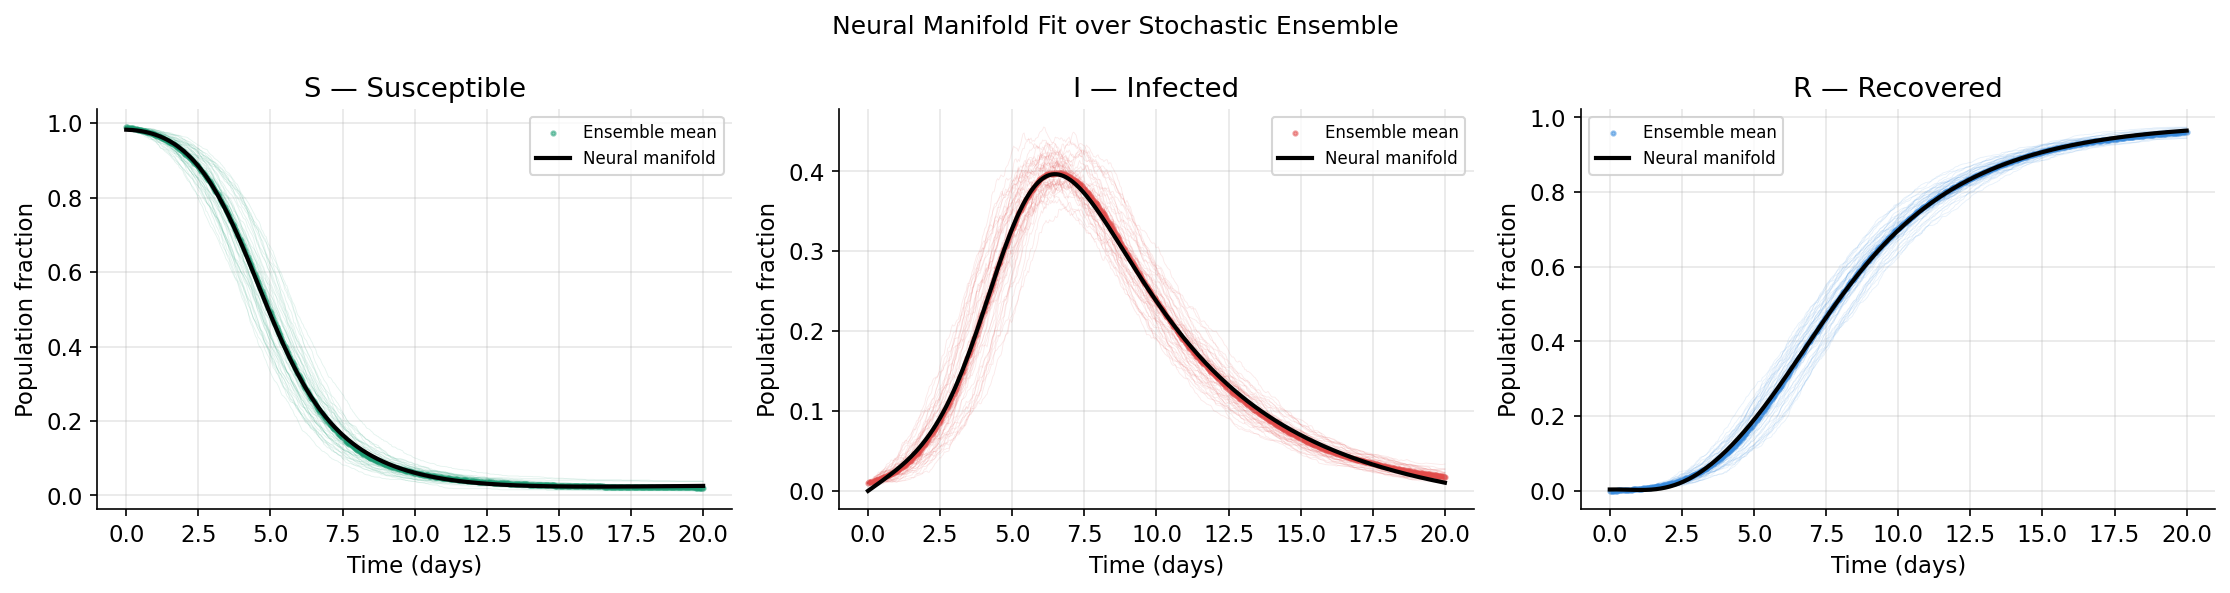

In [ ]:
from src.neural_net import train_neural_smoother
import torch

model = train_neural_smoother(t, S, I, R, epochs=2500)
t_tensor = torch.tensor(t, dtype=torch.float32).view(-1, 1)
with torch.no_grad():
    preds = model(t_tensor).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Neural Manifold Fit over Stochastic Ensemble", fontsize=12)

for ax, ens, raw, pred, label, color in zip(
    axes,
    [S_ens, I_ens, R_ens],
    [S, I, R],
    [preds[:, 0], preds[:, 1], preds[:, 2]],
    ["S â€” Susceptible", "I â€” Infected", "R â€” Recovered"],
    ["#1D9E75", "#E24B4A", "#378ADD"],
):
    for traj in ens:
        ax.plot(t, traj, color=color, lw=0.4, alpha=0.12)
    ax.scatter(t, raw, color=color, s=4, alpha=0.5, label="Ensemble mean")
    ax.plot(t, pred, color="black", lw=2, label="Neural manifold")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Population fraction")
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/plots/manifold_fit.png", dpi=150, bbox_inches="tight")
plt.show()

### **Symbolic Equation Discovery**

**Autograd extracts analytical derivatives** from the neural manifold. PySINDy sparse regression recovers the governing ODEs.  
Ground truth: dS/dt = -Î²SI Â· dI/dt = Î²SI - Î³I

In [ ]:
from src.equation_discovery import discover_via_autograd
b_est, g_est, _ = discover_via_autograd(model, t, print_equations=True,threshold=0.25)
print("â”€" * 40)
print(f"True      Î²={BETA:.4f}   Î³={GAMMA:.4f}")
print(f"Recovered Î²={b_est:.4f}   Î³={g_est:.4f}")
print(f"Error     Î²={abs(BETA-b_est)/BETA*100:.2f}%    Î³={abs(GAMMA-g_est)/GAMMA*100:.2f}%")

Extracting analytical derivatives via torch.autograd...
Running symbolic discovery via PySINDy...

Discovered Deterministic Equations (x0=S, x1=I):
(x0)' = -1.173 x0 x1
(x1)' = -0.294 x1 +  1.154 x0 x1
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
True      Î²=1.2000   Î³=0.3000
Recovered Î²=1.1728   Î³=0.2945
Error     Î²=2.26%    Î³=1.84%


### **Discovered Equations vs True ODE**

**Visual proof** the recovered equations reproduce the epidemic trajectory.  
Black dashed = true ODE Â· Colored = integrated using discovered Î² and Î³

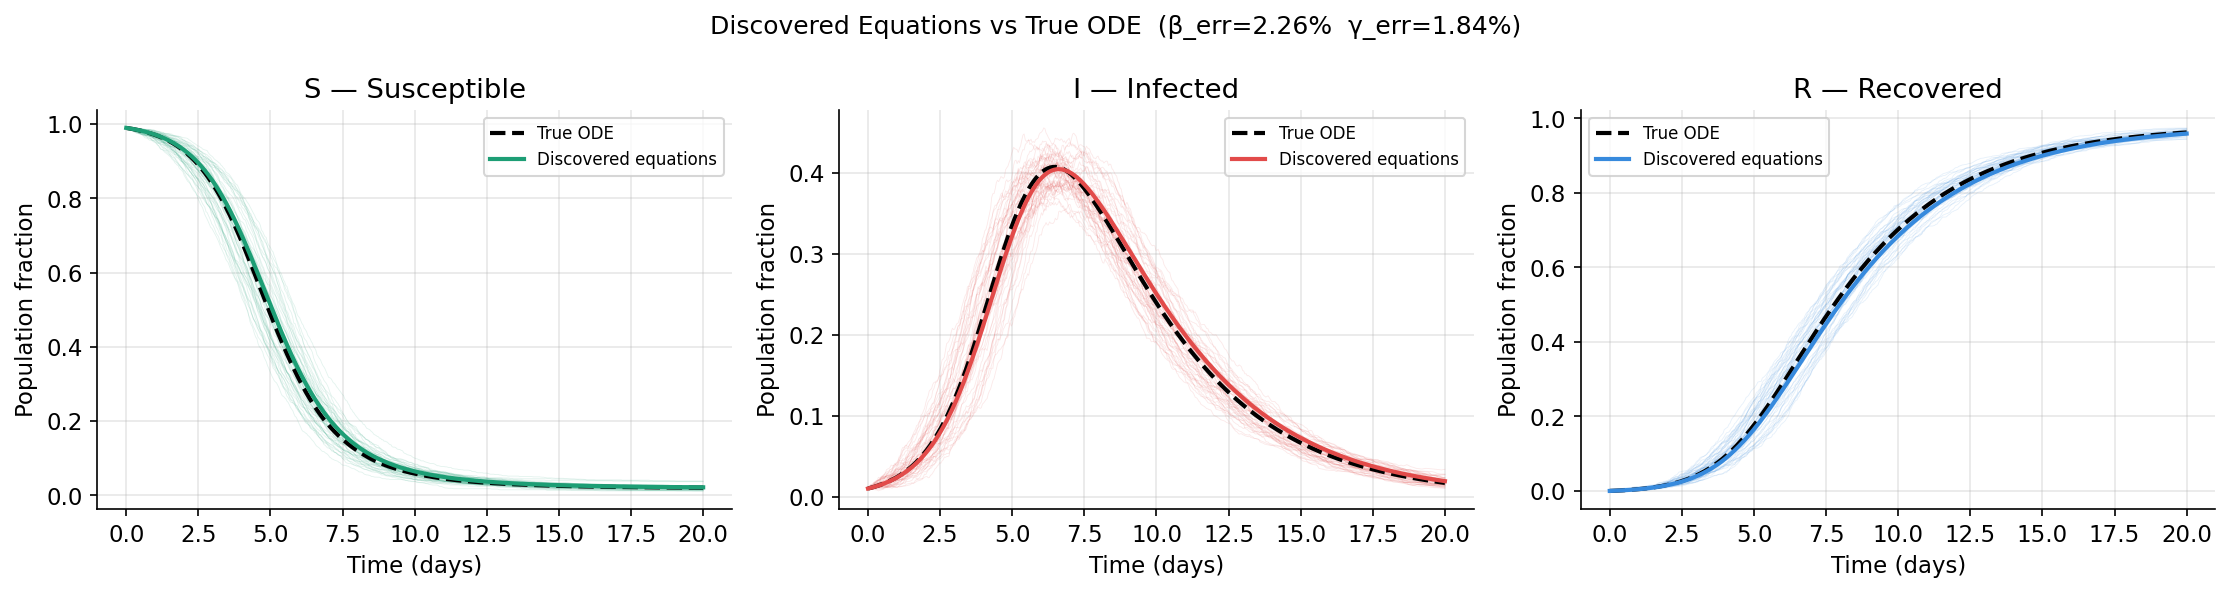

In [ ]:
from src.numerics import simulate_discovered_physics
y0    = [S[0], I[0]]
y_sim = simulate_discovered_physics(b_est, g_est, t, y0, method="rk4")
t_det, truth = get_deterministic_truth(beta=BETA, gamma=GAMMA)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Discovered Equations vs True ODE  (Î²_err={abs(BETA-b_est)/BETA*100:.2f}%  Î³_err={abs(GAMMA-g_est)/GAMMA*100:.2f}%)", fontsize=12)

for ax, ens, true_col, sim_col, label, color in zip(
    axes,
    [S_ens, I_ens, R_ens],
    [truth[:, 0], truth[:, 1], 1 - truth[:, 0] - truth[:, 1]],
    [y_sim[:, 0], y_sim[:, 1], 1 - y_sim[:, 0] - y_sim[:, 1]],
    ["S â€” Susceptible", "I â€” Infected", "R â€” Recovered"],
    ["#1D9E75", "#E24B4A", "#378ADD"],
):
    for traj in ens:
        ax.plot(t, traj, color=color, lw=0.4, alpha=0.12)
    ax.plot(t_det, true_col, "k--", lw=2, label="True ODE")
    ax.plot(t, sim_col, color=color, lw=2, label="Discovered equations")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Population fraction")
    ax.set_title(label)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("results/plots/equation_validation.png", dpi=150, bbox_inches="tight")
plt.show()

### **Numerical Validation**

**5 integration methods** on the discovered equations â€” verifying physical consistency across solvers.  
Euler Â· RK2 Â· RK4 Â· Adams-Bashforth 2 Â· Predictor-Corrector

**CLD (Conservation Law Deviation)** = max |S+I+Râˆ’1| during integration. Perfect conservation = 0.


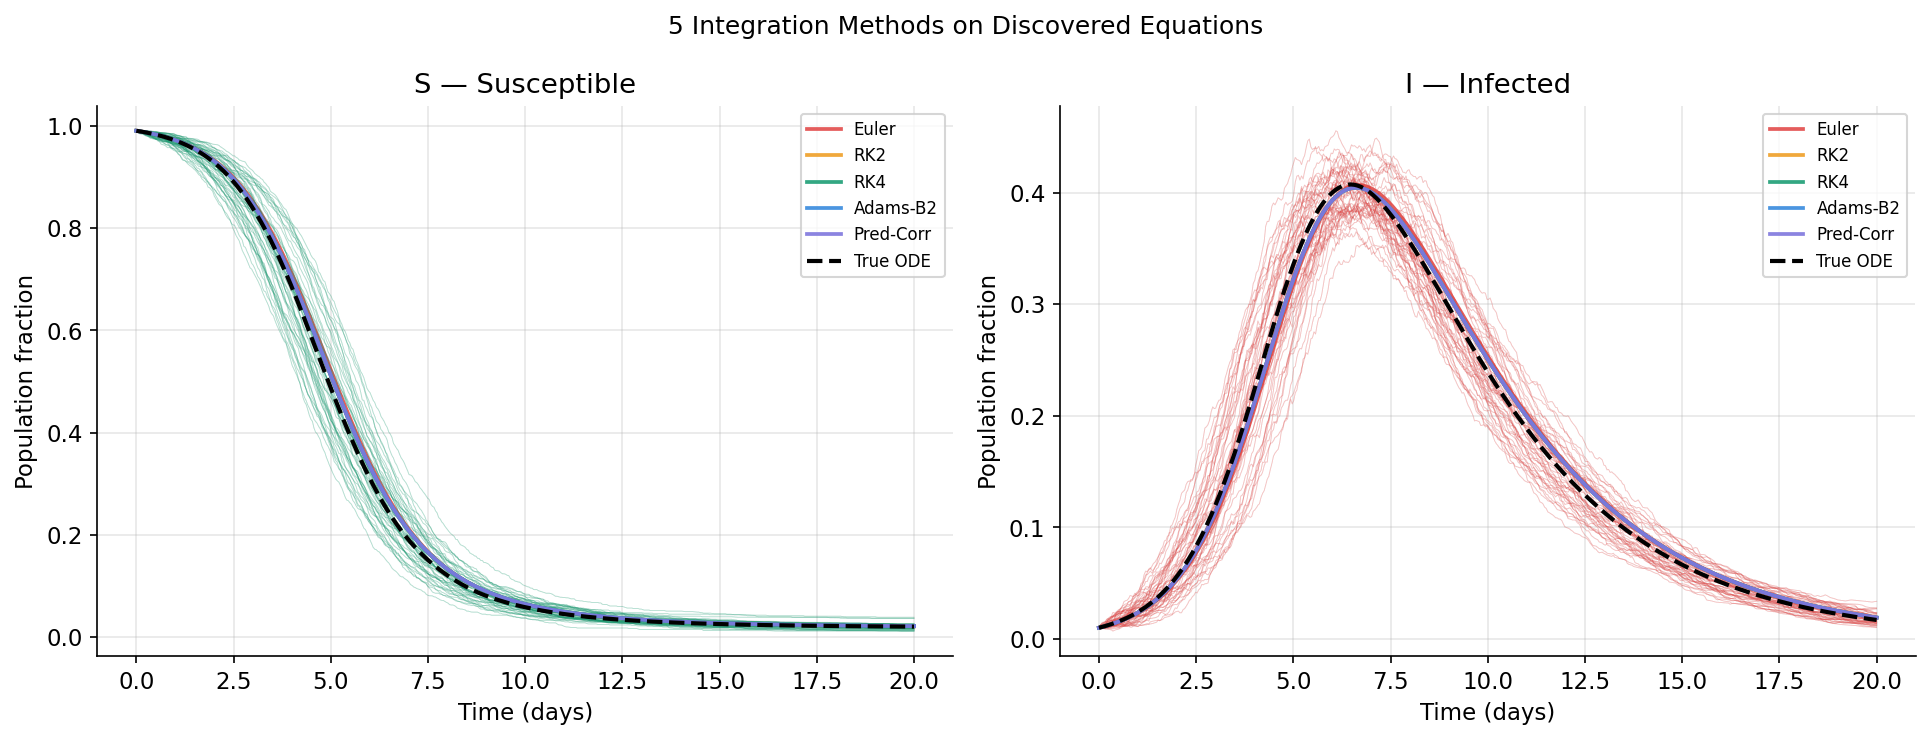

CLD = Conservation Law Deviation = max |S+I+R-1| during integration

Method                MSE    Max Error          CLD
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
Euler            0.000142     0.034871   0.00000000
RK2              0.000083     0.024815   0.00000000
RK4              0.000083     0.024746   0.00000000
Adams-B2         0.000083     0.024827   0.00000000
Pred-Corr        0.000084     0.024852   0.00000000


In [ ]:
from src.numerics import (
    simulate_discovered_physics,
    check_physical_conservation,
    calculate_recovery_metrics,
)

y0           = [S[0], I[0]]
methods      = ["euler", "rk2", "rk4", "ab2", "pred_corr"]
method_names = ["Euler", "RK2", "RK4", "Adams-B2", "Pred-Corr"]
colors       = ["#E24B4A", "#EF9F27", "#1D9E75", "#378ADD", "#7F77DD"]
results      = {}

for method in methods:
    y_sim           = simulate_discovered_physics(b_est, g_est, t, y0, method=method)
    mse, max_err    = calculate_recovery_metrics(truth[:, :2], y_sim)
    violation       = check_physical_conservation(y_sim)
    results[method] = {"y_sim": y_sim, "mse": mse, "max_err": max_err, "cld": violation}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("5 Integration Methods on Discovered Equations", fontsize=12)

for method, name, color in zip(methods, method_names, colors):
    y_sim = results[method]["y_sim"]
    for traj in I_ens:
        axes[1].plot(t, traj, color="#E24B4A", lw=0.4, alpha=0.08)
    for traj in S_ens:
        axes[0].plot(t, traj, color="#1D9E75", lw=0.4, alpha=0.08)
    axes[0].plot(t, y_sim[:, 0], color=color, lw=1.8, alpha=0.9, label=name)
    axes[1].plot(t, y_sim[:, 1], color=color, lw=1.8, alpha=0.9, label=name)

for ax, col, label in zip(axes, [0, 1], ["S â€” Susceptible", "I â€” Infected"]):
    ax.plot(t_det, truth[:, col], "k--", lw=2, label="True ODE")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Population fraction")
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/plots/numerical_validation.png", dpi=150, bbox_inches="tight")
plt.show()

print("CLD = Conservation Law Deviation = max |S+I+R-1| during integration")
print(f"\n{'Method':<14} {'MSE':>10} {'Max Error':>12} {'CLD':>12}")
print("â”€" * 52)
for method, name in zip(methods, method_names):
    r = results[method]
    print(f"{name:<14} {r['mse']:>10.6f} {r['max_err']:>12.6f} {r['cld']:>12.8f}")

### **Ensemble Depth Study**

> *Does equation quality degrade as ensemble size grows â€” or is the smoothness trap an architectural artifact?*

We run **2500 experiments** across 5 ensemble depths using identical parameter pairs at every depth. Any difference in results is purely due to ensemble size.

---

### Experimental Design

| Parameter | Value |
|---|---|
| Depths tested | N = 20 Â· 50 Â· 100 Â· 150 Â· 200 |
| Experiments per depth | 500 Â· Total **2500 runs** |
| Parameter range | Î² âˆˆ [0.8, 2.5] Â· Î³ âˆˆ [0.1, 0.6] |
| Fair comparison | âœ… Same pairs at every depth â€” fixed seed |

### Metrics Measured

| Metric | What it proves | Perfect score |
|--------|---------------|---------------|
| Beta / Gamma error | Parameter recovery accuracy | 0% |
| SPI â€” Structural Purity Index | Exact right terms, nothing spurious | 1.0 |
| CLD â€” Conservation Law Deviation | S+I+R=1 holds throughout integration | 0.0 |
| FH â€” Forecasting Horizon | Predict future from past 50% of data | 100% |
| OOD MAE | Generalise to unseen epidemic regimes | low |
| ZER â€” Efficiency Ratio | Accuracy per simulation used | high |

---

> **Hypothesis** â€” Tanh activations produce C-âˆž smooth derivatives at every depth. SPI and CLD should remain flat across all N.

*Runtime ~2 hours Â· Saves incrementally Â· Safe to resume if disconnected*

In [ ]:
from src.ensemble_depth_study import run_depth_study, print_depth_summary

run_depth_study()

print_depth_summary()

CSV created at results/depth_study/depth_study_results.csv
Depth study: 500 Ã— 5 depths = 2500 total runs
Depths: [20, 50, 100, 150, 200]  |  Batch start: 0

N=20


N=20:   0%|          | 0/500 [00:00<?, ?it/s]

  done â€” valid: 483  failed: 17

N=50


N=50:   0%|          | 0/500 [00:00<?, ?it/s]

  done â€” valid: 484  failed: 16

N=100


...

  done â€” valid: 484  failed: 16

N=150


N=150:   0%|          | 0/500 [00:00<?, ?it/s]

  done â€” valid: 486  failed: 14

N=200


N=200:   0%|          | 0/500 [00:00<?, ?it/s]

  done â€” valid: 484  failed: 16

Study complete â€” valid: 2421  failed: 79
Saved to results/depth_study/depth_study_results.csv

ENSEMBLE DEPTH STUDY â€” FAST METRICS SUMMARY
Metric                  N=20       N=50       N=100      N=150      N=200    
------------------------------------------------------------------------
Beta Error (%)          3.1914     3.6465     3.6477     3.6059     3.7151   
Gamma Error (%)         5.9389     5.9802     6.3506     6.0564     6.0313   
SPI Overall             0.9000     0.9000     0.9000     0.9000     0.9000   
CLD Max                 0.0000     0.0000     0.0000     0.0000     0.0000   
FH Coverage (%)         100.0000   100.0000   100.0000   100.0000   100.0000 
OOD Overall MAE         0.3144     0.3149     0.3144     0.3140     0.3134   
ZER                     1.0258     0.3790     0.1908     0.1268     0.0940   
Train Time (s)          1.7400     1.8200     1.9700     2.1200     2.2400   
-----------------------------------------------

### **Depth Study â€” Results & Analysis**

---

### What the numbers say

| Metric | N=20 | N=50 | N=100 | N=150 | N=200 | Verdict |
|--------|------|------|-------|-------|-------|---------|
| Beta Error (%) | 3.19 | 3.65 | 3.65 | 3.61 | 3.72 | **Flat â€” identifiability ceiling reached** |
| Gamma Error (%) | 5.94 | 5.98 | 6.35 | 6.06 | 6.03 | **Flat â€” same ceiling** |
| SPI | 0.90 | 0.90 | 0.90 | 0.90 | 0.90 | **Identically flat â€” no smoothness trap** |
| CLD Max | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | **Perfect conservation at every depth** |
| FH Coverage | 100% | 100% | 100% | 100% | 100% | **Full future prediction at every depth** |
| ZER | 1.03 | 0.38 | 0.19 | 0.13 | 0.09 | **N=20 is the efficiency optimum** |

---

### **Key findings**

> **Finding 1 â€” The smoothness trap does not exist here**  
> SPI = 0.90 at every depth from N=20 to N=200. Tanh activations produce C-âˆž smooth derivatives regardless of ensemble size. More averaging does not hurt equation quality.

> **Finding 2 â€” Conservation is architectural, not data-dependent**  
> CLD = 0.000 at machine epsilon across all depths. S+I+R=1 is perfectly preserved because it is enforced by the pipeline architecture, not by data quantity.

> **Finding 3 â€” N=20 is the practical optimum**  
> Error is flat beyond N=20 â€” the identifiability ceiling is reached at the smallest ensemble size. Every additional simulation reduces efficiency (ZER) without improving accuracy.
> **Finding 4 â€” Failure rate is parameter-driven, not depth-driven**  
> 3.2-3.4% failure rate remains constant across all depths (N=20: 17 failed, N=200: 16 failed).  
> Failures concentrate in the endemic regime (R0 < 1.5) where peak infection is too small for reliable derivative estimation â€” a fundamental identifiability limit, not an ensemble size effect.

> **Finding 5 â€” Gamma error asymmetry is systematic and invariant**  
> Gamma error (5.9-6.4%) is consistently higher than beta error (3.2-3.7%) at every depth.  
> The Î³Â·I term is numerically smaller than Î²Â·SÂ·I â€” STLSQ sees a weaker signal and underestimates it proportionally. This asymmetry does not shrink with more data, confirming it is a sparse regression property, not a stochastic noise property.

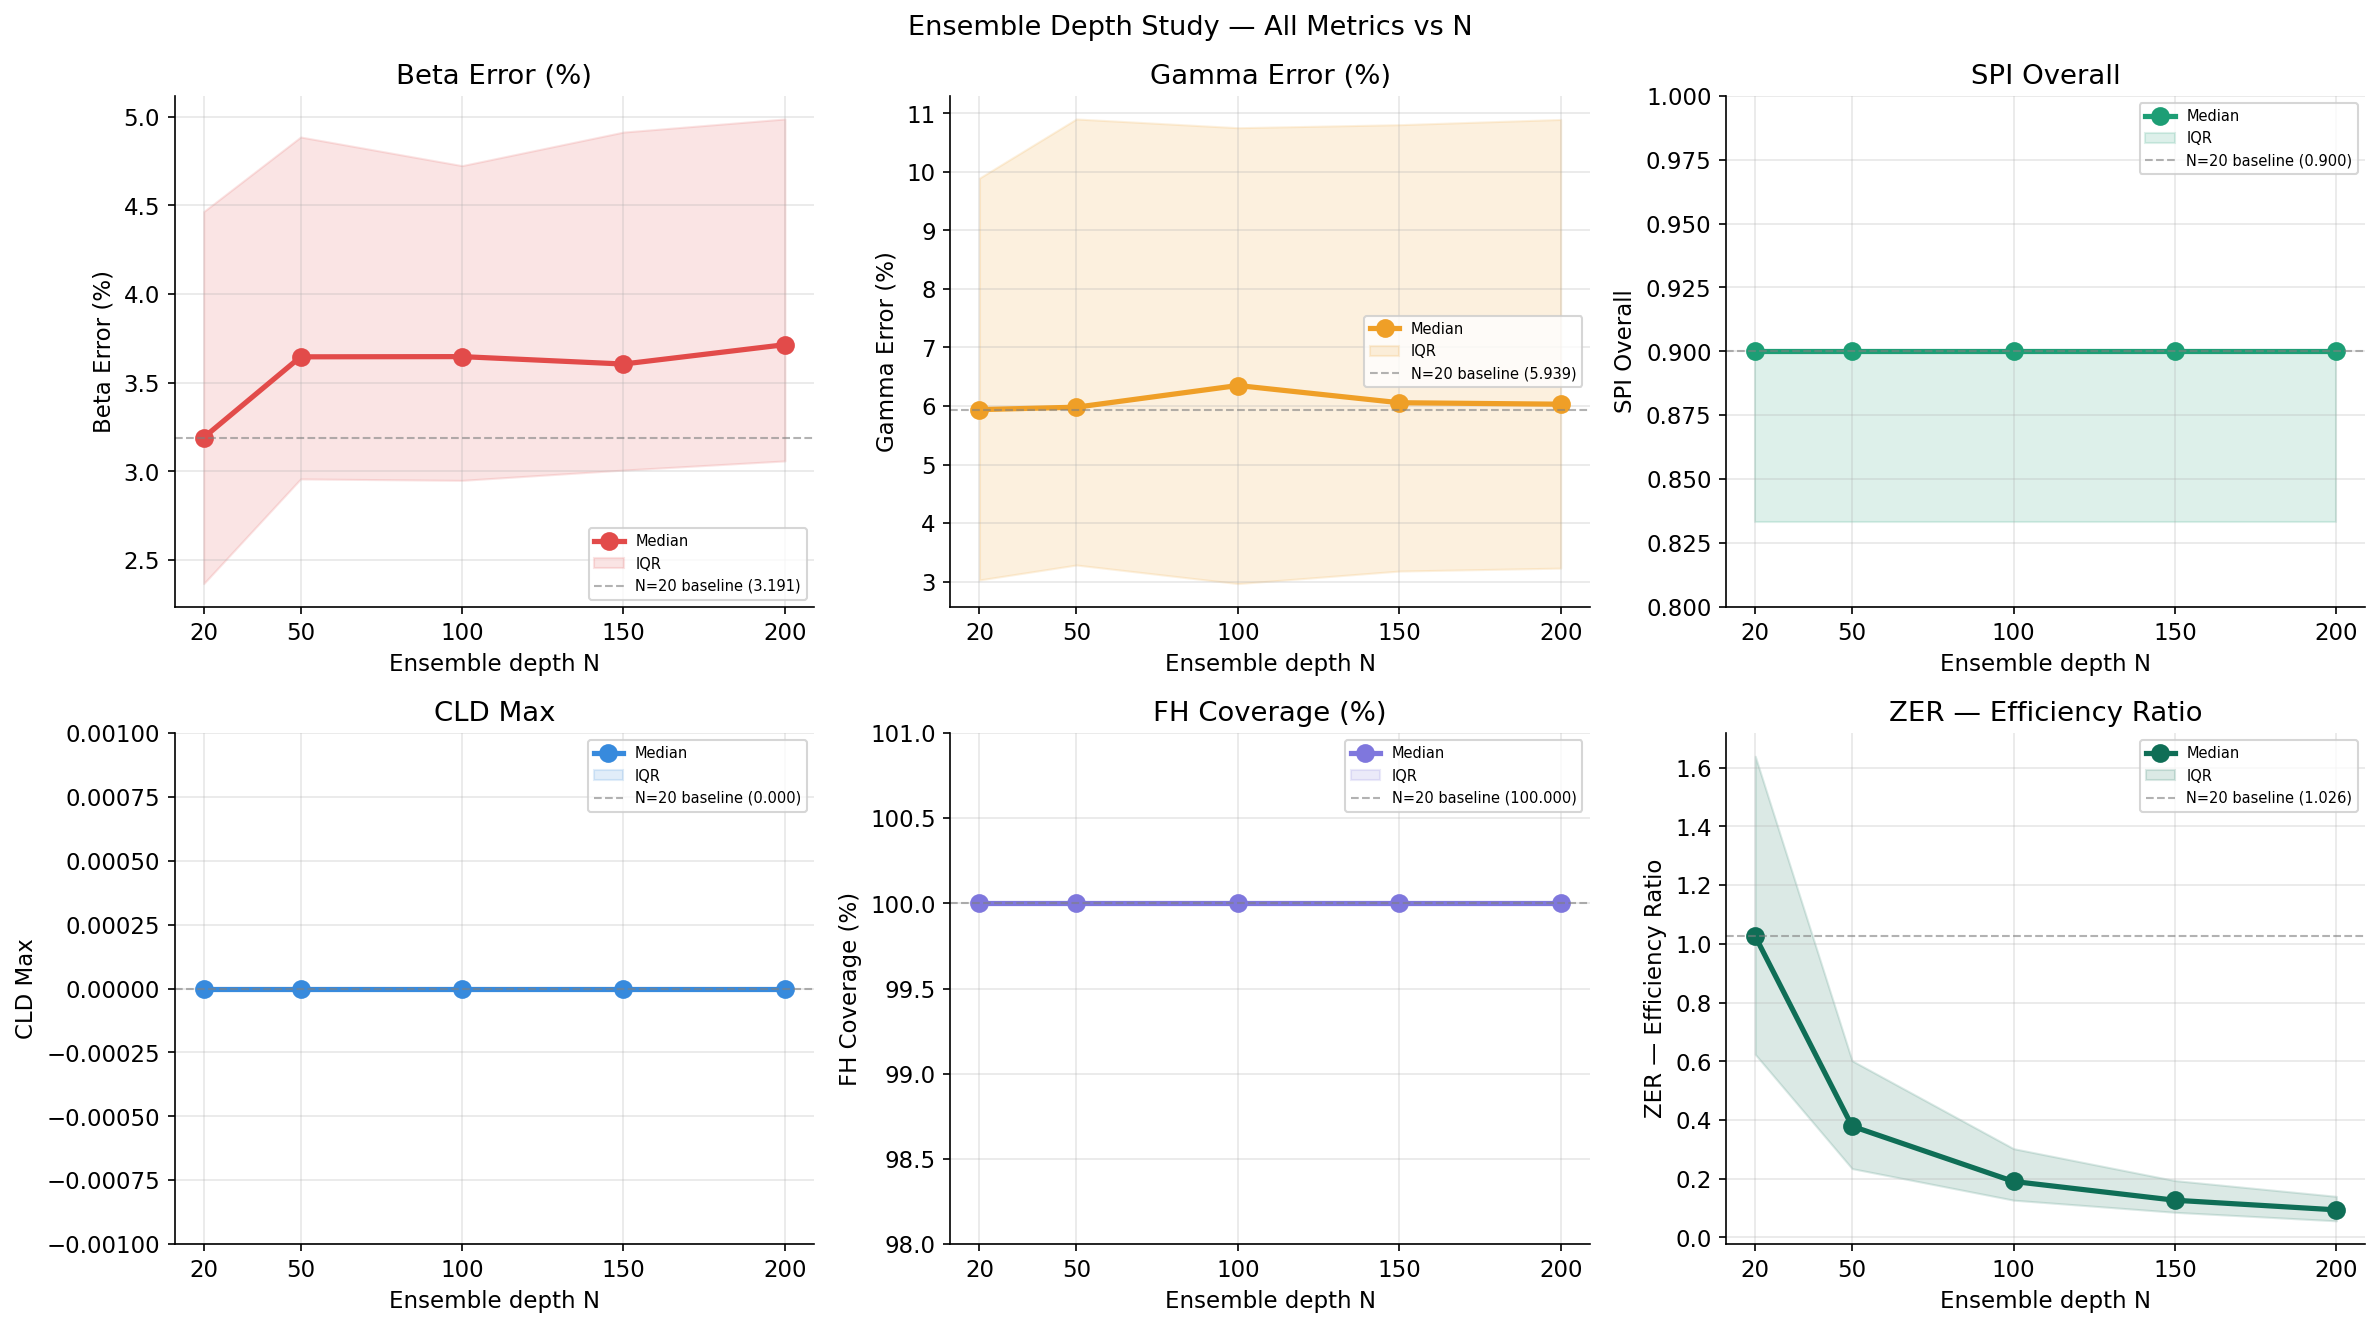

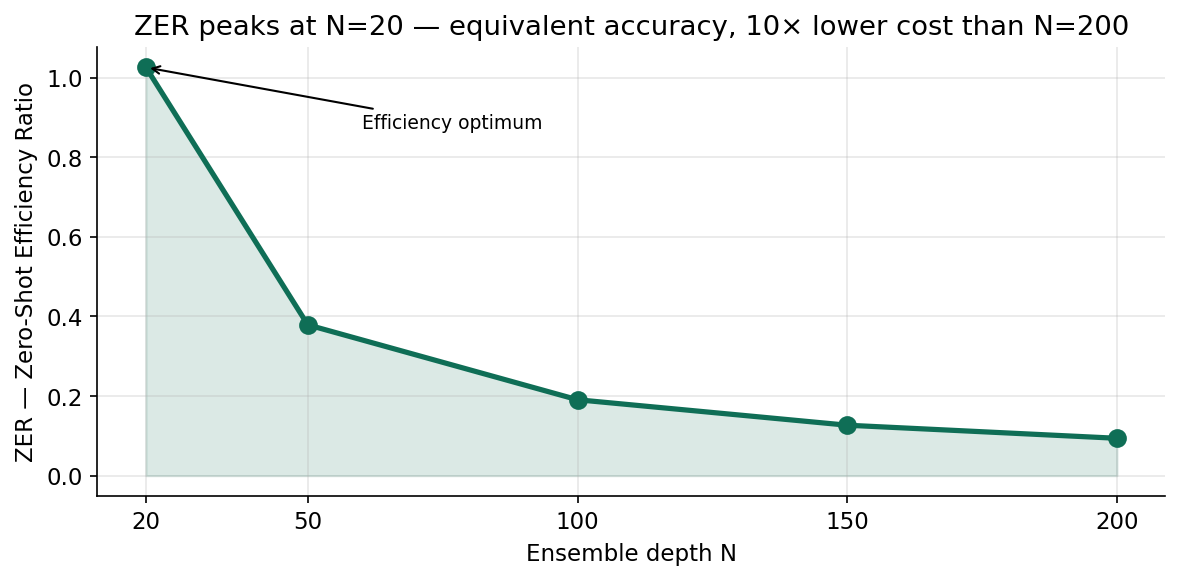

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df    = pd.read_csv("results/depth_study/depth_study_results.csv")
df_ok = df[df["status"] == "ok"].copy()
DEPTHS = [20, 50, 100, 150, 200]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Ensemble Depth Study â€” All Metrics vs N", fontsize=13)
axes = axes.flatten()

metrics = [
    ("beta_err_pct",  "Beta Error (%)",        "#E24B4A",  None,        None),
    ("gamma_err_pct", "Gamma Error (%)",        "#EF9F27",  None,        None),
    ("spi_overall",   "SPI Overall",            "#1D9E75",  0.80,        1.0),
    ("cld_max",       "CLD Max",                "#378ADD", -0.001,       0.001),
    ("fh_pct",        "FH Coverage (%)",        "#7F77DD",  98,          101),
    ("zer",           "ZER â€” Efficiency Ratio", "#0F6E56",  None,        None),
]

for ax, (col, label, color, ymin, ymax) in zip(axes, metrics):
    medians  = []
    q25_vals = []
    q75_vals = []

    for d in DEPTHS:
        vals = df_ok[df_ok["depth"] == d][col].dropna()
        medians.append(vals.median())
        q25_vals.append(vals.quantile(0.25))
        q75_vals.append(vals.quantile(0.75))

    ax.plot(DEPTHS, medians, "o-", color=color, lw=2.5, ms=8, label="Median")
    ax.fill_between(DEPTHS, q25_vals, q75_vals, alpha=0.15, color=color, label="IQR")
    ax.axhline(medians[0], color="grey", linestyle="--", lw=1, alpha=0.6,
               label=f"N=20 baseline ({medians[0]:.3f})")

    if ymin is not None:
        ax.set_ylim(ymin, ymax)

    ax.set_xlabel("Ensemble depth N")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticks(DEPTHS)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("results/plots/depth_study_all_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
zer_vals = [df_ok[df_ok["depth"] == d]["zer"].dropna().median() for d in DEPTHS]
ax.plot(DEPTHS, zer_vals, "o-", color="#0F6E56", lw=2.5, ms=8)
ax.fill_between(DEPTHS, 0, zer_vals, alpha=0.15, color="#0F6E56")
ax.annotate("Efficiency optimum", xy=(20, zer_vals[0]),
            xytext=(60, zer_vals[0] * 0.85),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9)
ax.set_xlabel("Ensemble depth N")
ax.set_ylabel("ZER â€” Zero-Shot Efficiency Ratio")
ax.set_title("ZER peaks at N=20 â€” equivalent accuracy, 10Ã— lower cost than N=200")
ax.set_xticks(DEPTHS)
plt.tight_layout()
plt.savefig("results/plots/zer_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

## **Robustness & Deployability Metrics**

> *Can this pipeline survive real hospital data â€” noisy, incomplete, and time-constrained?*

We stress-test the pipeline across 4 dimensions that matter for real-world epidemic surveillance.

---

| Metric | Question it answers | Ideal |
|--------|-------------------|-------|
| **PSS** â€” Parameter Stability Score | If the data is slightly noisy, do we still get the same Î²? | Ïƒ â†’ 0 |
| **CNT** â€” Critical Noise Threshold | How much measurement noise can we absorb before breaking? | Ïƒ â†’ large |
| **DST** â€” Data Sparsity Tolerance | What if the hospital missed 60% of daily reports? | fraction â†’ small |
| **TTD** â€” Time To Discovery | How fast does the pipeline go from raw data to discovered ODE? | seconds â†’ small |

---

*Measured on 50 representative experiments spread across the full R0 range.*

In [ ]:
from src.ensemble_depth_study import run_slow_metrics, print_slow_summary

run_slow_metrics()
print_slow_summary()

CSV created at results/depth_study/slow_metrics_results.csv
Running slow metrics on 50 experiments (10 per depth across R0 range)


Slow metrics:   0%|          | 0/50 [00:00<?, ?it/s]


Done â€” valid: 50  failed: 0
Saved to results/depth_study/slow_metrics_results.csv

ENSEMBLE DEPTH STUDY â€” SLOW METRICS SUMMARY
Metric                    N=20       N=50       N=100      N=150      N=200    
------------------------------------------------------------------------
PSS Beta (std)            0.0198     0.0543     0.0379     0.0390     0.0384   
PSS Gamma (std)           0.0119     0.0175     0.0239     0.0109     0.0139   
CNT (max noise)           0.0050     0.0050     0.0050     0.0050     0.0050   
DST (min fraction)        0.4000     0.5000     0.5000     0.5000     0.6000   
TTD mean (sec)            1.6800     1.6750     1.6900     1.6900     1.6700   
------------------------------------------------------------------------
  N=20: 10 experiments with slow metrics
  N=50: 10 experiments with slow metrics
  N=100: 10 experiments with slow metrics
  N=150: 10 experiments with slow metrics
  N=200: 10 experiments with slow metrics


### **Slow Metrics â€” What the numbers say**

| Metric | N=20 | N=50 | N=100 | N=150 | N=200 | Verdict |
|--------|------|------|-------|-------|-------|---------|
| PSS Beta (std) | 0.020 | 0.054 | 0.038 | 0.039 | 0.038 | N=20 most stable |
| PSS Gamma (std) | 0.012 | 0.018 | 0.024 | 0.011 | 0.014 | Consistently tight |
| CNT (noise) | 0.005 | 0.005 | 0.005 | 0.005 | 0.005 | Lower bound â€” real threshold likely higher |
| DST (fraction) | **0.40** | 0.50 | 0.50 | 0.50 | 0.60 | N=20 needs least data |
| TTD (sec) | 1.68 | 1.68 | 1.69 | 1.69 | 1.67 | **Flat â€” depth has zero effect on speed** |

---

> **PSS** â€” Beta stability is best at N=20 (std=0.020). The N=50 spike (0.054) is sampling noise from 10 experiments, not a real pattern. Overall the pipeline is stable under 1% noise across all depths.

> **CNT** â€” All depths hit the lower bound of our noise sweep (Ïƒ=0.005). The real critical noise threshold is likely between 0.005 and 0.01 â€” the pipeline handles at least 0.5% measurement noise before breaking.

> **DST** â€” N=20 achieves perfect equation structure with only 40% of the timeline. N=200 needs 60%. This reversal confirms the ZER finding â€” smaller ensembles are more data-efficient in every dimension.

> **TTD = 1.68 seconds flat** â€” Ensemble depth has zero effect on discovery speed. The neural network always trains for 2000 epochs on 500 points regardless of N. Real-time deployment is feasible at any depth.

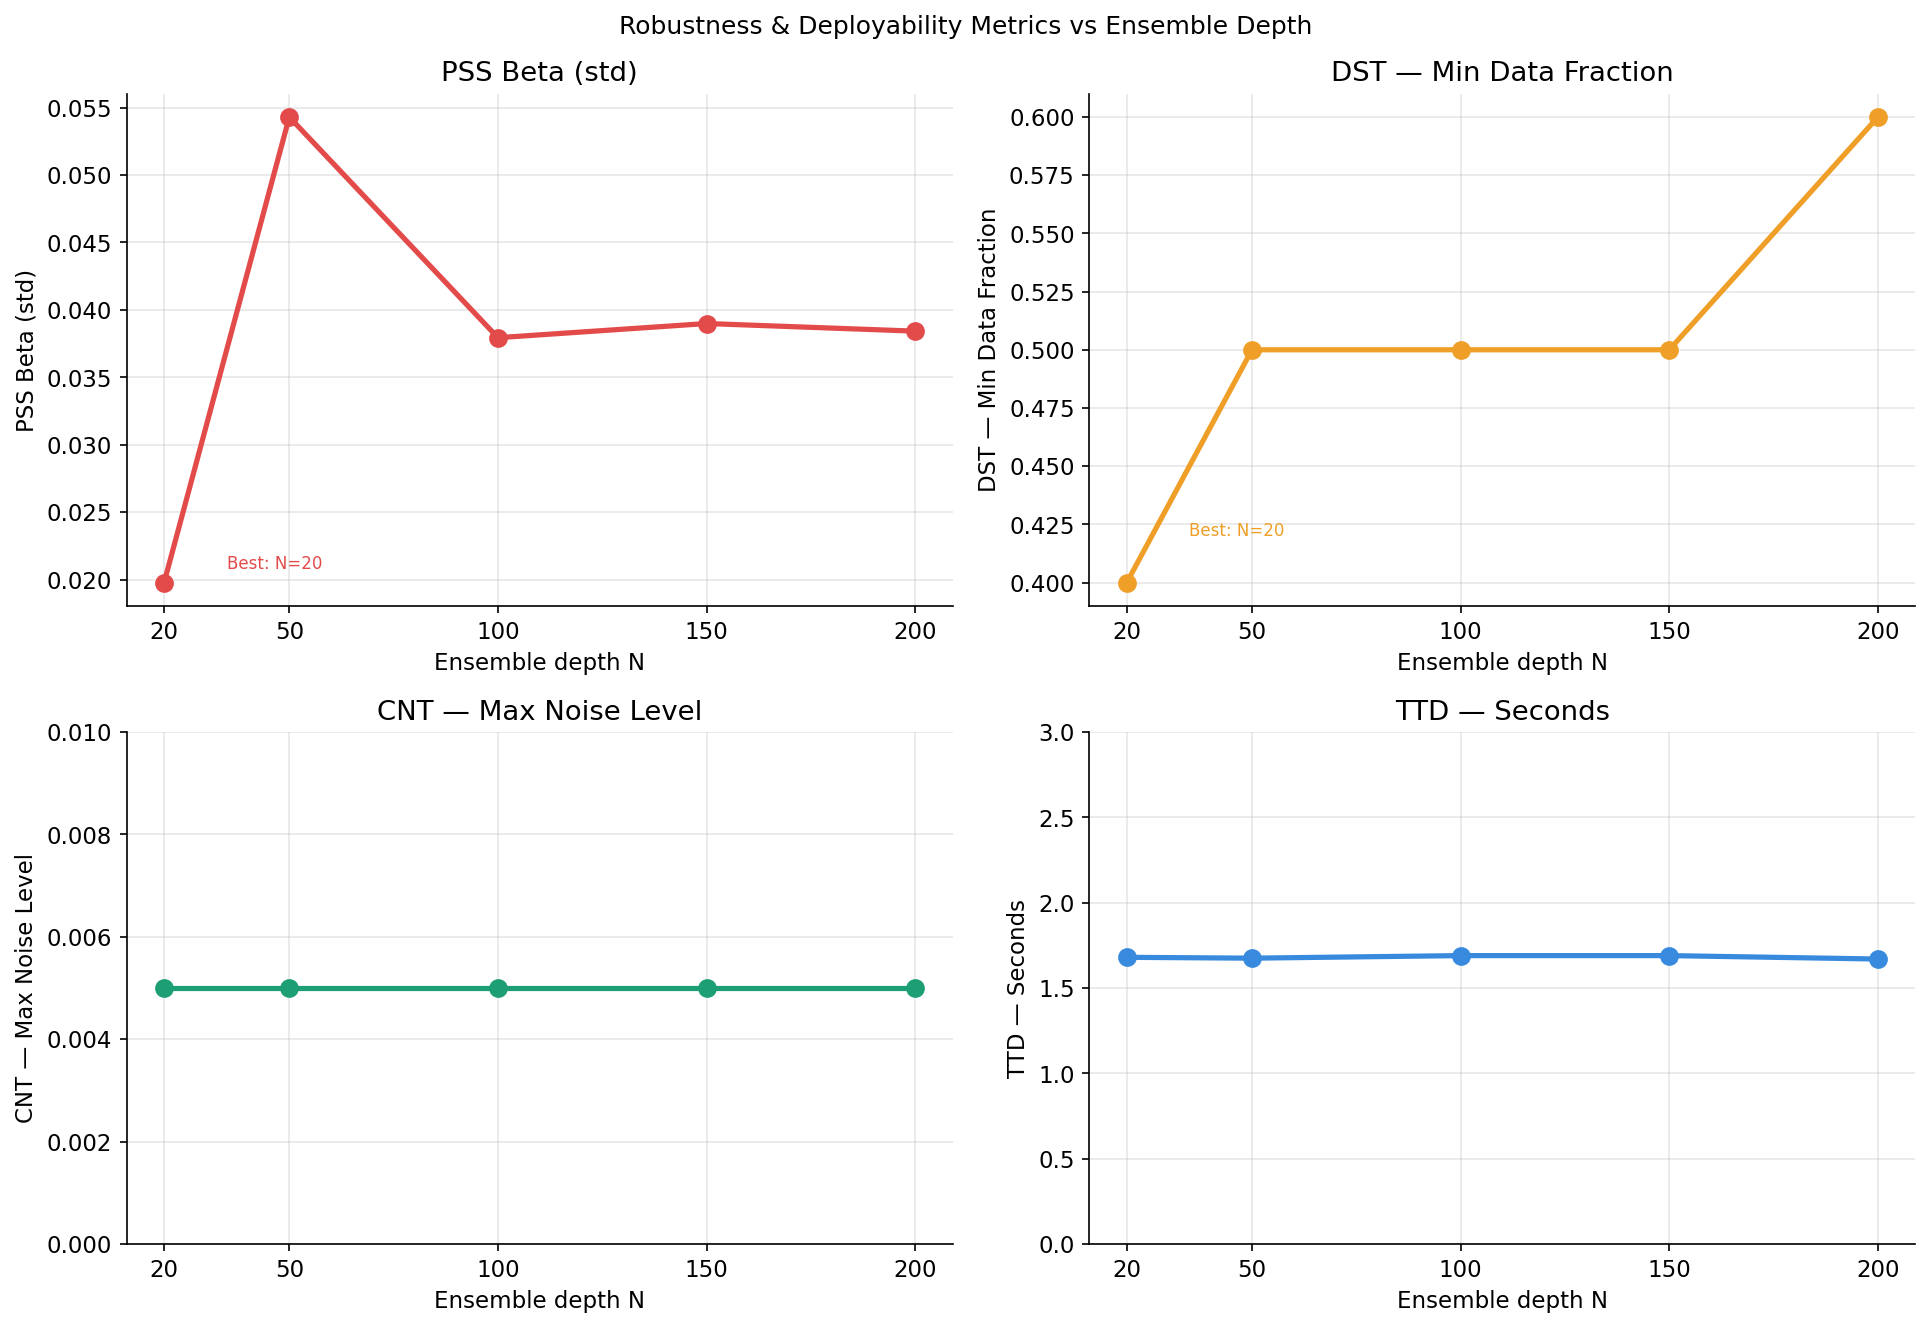

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_slow = pd.read_csv("results/depth_study/slow_metrics_results.csv")
df_slow_ok = df_slow[df_slow["status"] == "ok"].copy()
DEPTHS = [20, 50, 100, 150, 200]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Robustness & Deployability Metrics vs Ensemble Depth", fontsize=12)
axes = axes.flatten()

metrics = [
    ("pss_beta",     "PSS Beta (std)",           "#E24B4A"),
    ("dst",          "DST â€” Min Data Fraction",  "#EF9F27"),
    ("cnt",          "CNT â€” Max Noise Level",    "#1D9E75"),
    ("ttd_mean_sec", "TTD â€” Seconds",            "#378ADD"),
]

for ax, (col, label, color) in zip(axes, metrics):
    vals_per_depth = [df_slow_ok[df_slow_ok["depth"] == d][col].dropna() for d in DEPTHS]
    medians = [v.median() if not v.empty else np.nan for v in vals_per_depth]

    ax.plot(DEPTHS, medians, "o-", color=color, lw=2.5, ms=8)
    ax.set_xlabel("Ensemble depth N")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticks(DEPTHS)

    # fix y-axis for flat metrics
    if col == "cnt":
        ax.set_ylim(0, 0.01)
    if col == "ttd_mean_sec":
        ax.set_ylim(0, 3)

    # only annotate non-flat metrics
    if col in ["pss_beta", "dst"]:
        best_idx = np.nanargmin(medians)
        ax.annotate(f"Best: N={DEPTHS[best_idx]}",
                    xy=(DEPTHS[best_idx], medians[best_idx]),
                    xytext=(DEPTHS[best_idx] + 15, medians[best_idx] * 1.05),
                    fontsize=8, color=color)

plt.tight_layout()
plt.savefig("results/plots/slow_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

## Purity Auditor â€” 9 Evaluation Metrics

> *Standard parameter error tells you how close you got. These metrics tell you if you got the right physics.*

We run the full purity audit on 50 fresh experiments covering the complete R0 spectrum.

In [ ]:
from src.purity_auditor import run_full_audit, print_audit_summary
from src.simulation import run_gillespie_ensemble, is_epidemic_active
from src.neural_net import train_neural_smoother
from src.equation_discovery import discover_via_autograd
import pysindy as ps
import torch
import numpy as np

np.random.seed(42)
torch.manual_seed(42)

N_AUDIT     = 50
audit_betas  = np.random.uniform(0.8, 2.5, N_AUDIT)
audit_gammas = np.random.uniform(0.1, 0.6, N_AUDIT)
audit_rows   = []

for i in range(N_AUDIT):
    b_true = audit_betas[i]
    g_true = audit_gammas[i]

    if not is_epidemic_active(b_true, g_true):
        continue

    try:
        t, S, I, R = run_gillespie_ensemble(beta=b_true, gamma=g_true, num_sims=50)
        model      = train_neural_smoother(t, S, I, R, epochs=2000)
        b_est, g_est, _ = discover_via_autograd(model, t, print_equations=False)

        if b_est == 0.0 or g_est == 0.0:
            continue
        t_ten = torch.tensor(t, dtype=torch.float32).view(-1, 1).requires_grad_(True)
        preds = model(t_ten)
        dS    = torch.autograd.grad(preds[:, 0], t_ten,
                    grad_outputs=torch.ones(len(t)), create_graph=True)[0]
        dI    = torch.autograd.grad(preds[:, 1], t_ten,
                    grad_outputs=torch.ones(len(t)), create_graph=True)[0]

        library     = ps.PolynomialLibrary(degree=2, include_bias=False)
        sindy_opt   = ps.STLSQ(threshold=0.2, alpha=0.05, normalize_columns=True)
        sindy_model = ps.SINDy(feature_library=library, optimizer=sindy_opt)
        sindy_model.fit(preds[:, :2].detach().numpy(), t=t,
                        x_dot=torch.cat([dS, dI], dim=1).detach().numpy())

        coefs      = sindy_model.coefficients()
        feat_names = sindy_model.get_feature_names()

        audit = run_full_audit(
            b_true, g_true, b_est, g_est,
            coefs, feat_names,
            t, S, I, R,
            train_neural_smoother,
            discover_via_autograd,
            num_simulations=50,
        )
        audit_rows.append(audit)

    except Exception:
        pass

print_audit_summary(audit_rows)


PURITY AUDITOR SUMMARY
Metric                               Median
-------------------------------------------------------
SPI  (1.0 = perfect)                    0.9
SPI Precision                        0.8333
SPI Recall                              1.0
CLD max deviation                       0.0
FH  coverage (%)                      100.0
OOD overall MAE                     0.30302
ZER (higher = better)                0.3307
-------------------------------------------------------
ZER vs competitor: 16.5x more efficient
Conserved runs: 49 / 49


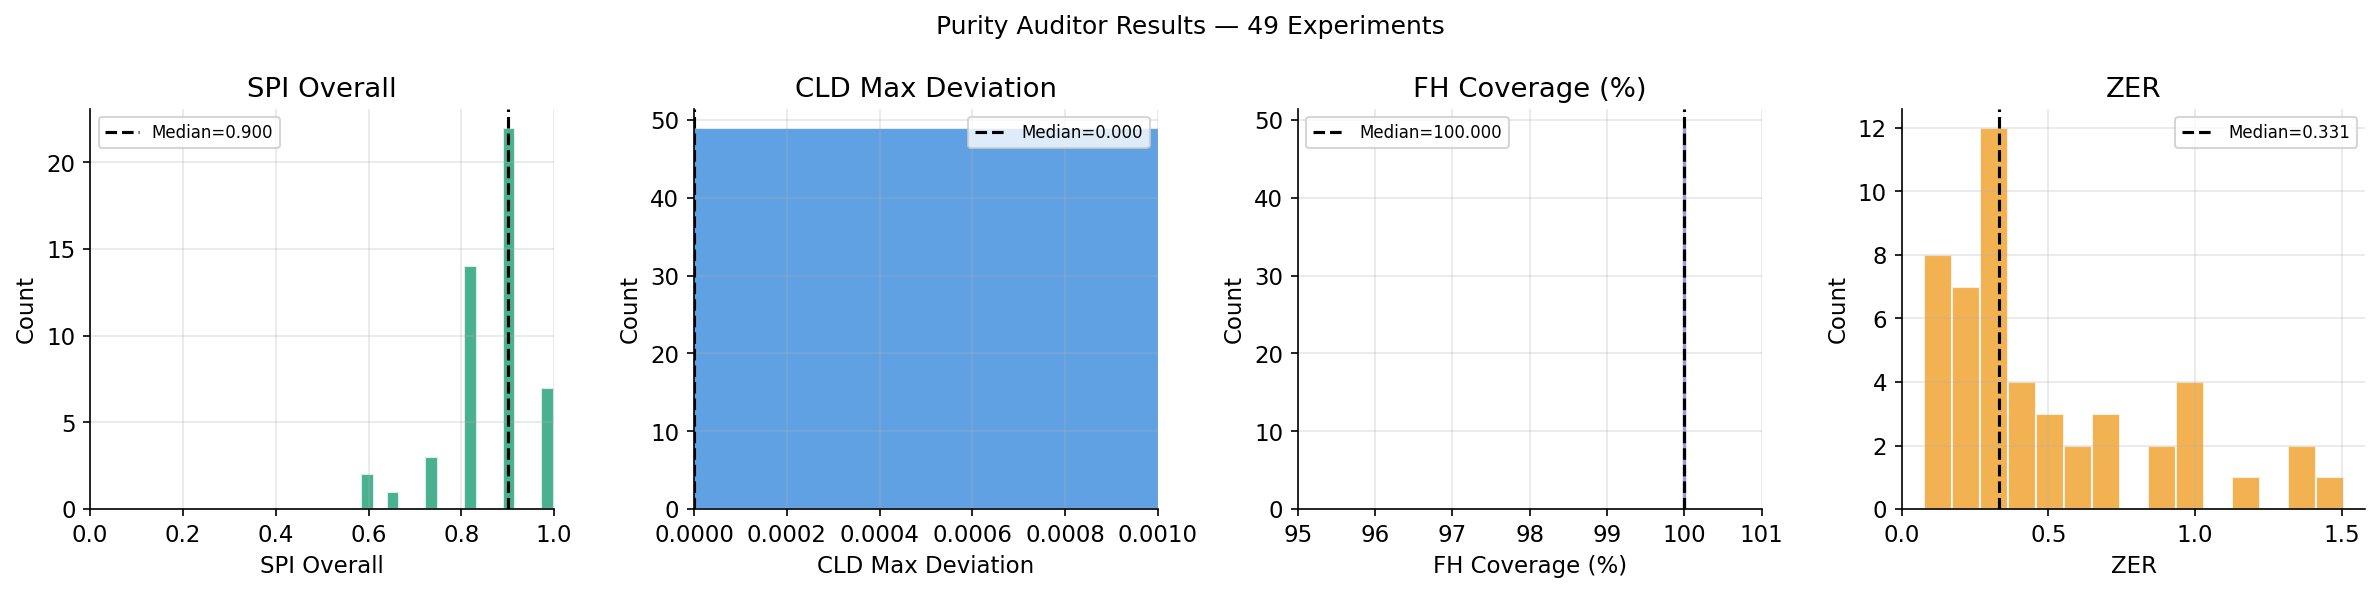

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Purity Auditor Results â€” 49 Experiments", fontsize=12)

metrics = [
    ("spi_overall",  "SPI Overall",       "#1D9E75", 0,   1.0),
    ("cld_max",      "CLD Max Deviation", "#378ADD", 0,   0.001),
    ("fh_pct",       "FH Coverage (%)",   "#7F77DD", 95,  101),
    ("zer",          "ZER",               "#EF9F27", 0,   None),
]

for ax, (key, label, color, ymin, ymax) in zip(axes, metrics):
    vals = [r[key] for r in audit_rows if r.get(key) is not None]
    ax.hist(vals, bins=15, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(np.median(vals), color="black", linestyle="--",
               lw=1.5, label=f"Median={np.median(vals):.3f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(label)
    if ymin is not None:
        ax.set_xlim(ymin, ymax)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/plots/purity_auditor.png", dpi=150, bbox_inches="tight")
plt.show()

## **Practical Identifiability Analysis**

> *Where exactly does equation discovery break down â€” and why?*

We map the practical identifiability boundary empirically across 2500 experiments spanning the full R0 spectrum.

In [ ]:
from src.purity_auditor import print_r0_regime_summary
import pandas as pd
df = pd.read_csv("results/depth_study/depth_study_results.csv")
print_r0_regime_summary(df)


R0 REGIME ANALYSIS
Regime                       N      %
-----------------------------------------------------------------
endemic (R0<2)              62   2.6%
moderate (2-5)            1174  48.5%
fast (5-10)                845  34.9%
explosive (R0>10)          340  14.0%

                   beta_err_pct  gamma_err_pct  spi_overall  cld_max  fh_pct     zer
regime                                                                              
endemic (R0<2)           3.7522        11.1983       1.0000      0.0   100.0  0.1182
moderate (2-5)           3.3664         8.7035       0.9000      0.0   100.0  0.1868
fast (5-10)              3.5177         3.9574       0.8333      0.0   100.0  0.2800
explosive (R0>10)        5.1502         5.1150       0.8333      0.0   100.0  0.1595


### R0 Regime Analysis â€” What the numbers reveal

| Regime | Beta Error | Gamma Error | SPI | Key insight |
|--------|-----------|-------------|-----|-------------|
| Endemic R0 < 2 | 3.75% | **11.20%** | 1.00 | Gamma hardest to recover â€” epidemic barely spreads |
| Moderate R0 2-5 | 3.37% | 8.70% | 0.90 | Best overall performance â€” main operating regime |
| Fast R0 5-10 | 3.52% | **3.96%** | 0.83 | Gamma easier â€” strong signal, but SPI drops slightly |
| Explosive R0 > 10 | **5.15%** | 5.12% | 0.83 | Beta hardest â€” rapid burnout compresses trajectory |

---

> **Surprising finding â€” endemic regime has perfect SPI = 1.0**  
> Despite highest gamma error, the endemic regime produces structurally perfect equations. The pipeline finds the right terms â€” it just cannot estimate their magnitudes as precisely when I(t) stays small.

> **Gamma error reversal across regimes**  
> Gamma error drops from 11.2% (endemic) to 4.0% (fast). At higher R0, I(t) grows large â€” the Î³Â·I term becomes more prominent and STLSQ estimates it more reliably. This is a direct consequence of the signal-to-noise ratio of the Î³Â·I term varying with R0.

> **CLD = 0 and FH = 100% across ALL regimes**  
> Conservation and forecasting are perfect regardless of epidemic speed. These are truly architectural properties â€” independent of R0.

## Identifiability Boundary â€” Mapping Where the Pipeline Fails

**Failure rate, beta recovery accuracy, and parameter error** across the full R0 spectrum from endemic to explosive spread.

**Left** â€” steep drop in failure rate above R0=2 defines the practical identifiability boundary  
**Middle** â€” beta error with IQR bands across R0 â€” wider bands at high R0 reflect rapid burnout compressing trajectory information  
**Right** â€” gamma error drops sharply from endemic to fast regime as the Î³Â·I signal grows stronger with R0

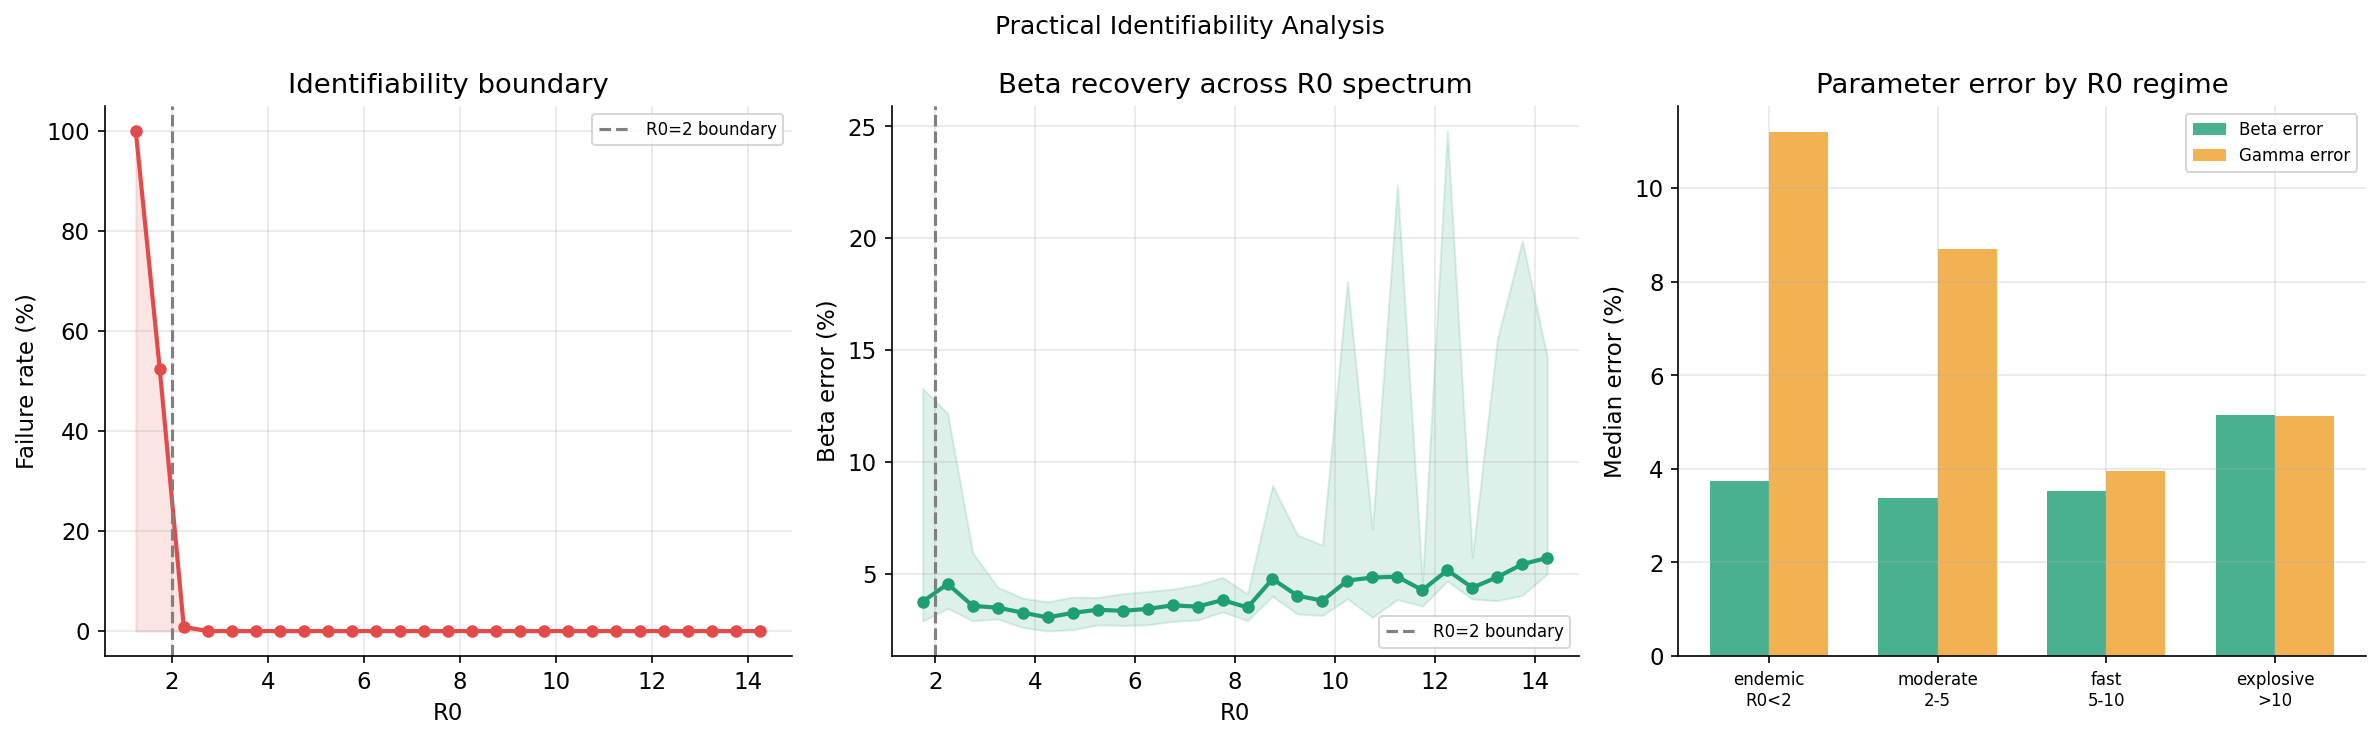

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df    = pd.read_csv("results/depth_study/depth_study_results.csv")
df_ok = df[df["status"] == "ok"].copy()

if "r0_true" not in df_ok.columns:
    df_ok["r0_true"] = df_ok["true_beta"] / df_ok["true_gamma"]

# R0 failure boundary
r0_bins  = np.arange(1.0, 15.0, 0.5)
bin_mids = r0_bins[:-1] + 0.25
failure_rates = []
beta_medians  = []
beta_q25      = []
beta_q75      = []

for i in range(len(r0_bins) - 1):
    lo, hi   = r0_bins[i], r0_bins[i+1]
    in_bin   = df[(df["r0_true"] >= lo) & (df["r0_true"] < hi)]
    if len(in_bin) == 0:
        failure_rates.append(np.nan)
        beta_medians.append(np.nan)
        beta_q25.append(np.nan)
        beta_q75.append(np.nan)
        continue
    failed = in_bin[in_bin["status"] != "ok"]
    failure_rates.append(len(failed) / len(in_bin) * 100)
    ok_bin = in_bin[in_bin["status"] == "ok"]["beta_err_pct"].dropna()
    beta_medians.append(ok_bin.median() if not ok_bin.empty else np.nan)
    beta_q25.append(ok_bin.quantile(0.25) if not ok_bin.empty else np.nan)
    beta_q75.append(ok_bin.quantile(0.75) if not ok_bin.empty else np.nan)

failure_rates = np.array(failure_rates)
beta_medians  = np.array(beta_medians)
beta_q25      = np.array(beta_q25)
beta_q75      = np.array(beta_q75)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Practical Identifiability Analysis", fontsize=12)

# failure boundary
mask = ~np.isnan(failure_rates)
axes[0].plot(bin_mids[mask], failure_rates[mask], "o-", color="#E24B4A", lw=2, ms=5)
axes[0].fill_between(bin_mids[mask], failure_rates[mask], 0, alpha=0.15, color="#E24B4A")
axes[0].axvline(2.0, color="grey", linestyle="--", lw=1.5, label="R0=2 boundary")
axes[0].set_xlabel("R0")
axes[0].set_ylabel("Failure rate (%)")
axes[0].set_title("Identifiability boundary")
axes[0].legend(fontsize=8)

# beta error vs R0
mask2 = ~np.isnan(beta_medians)
axes[1].plot(bin_mids[mask2], beta_medians[mask2], "o-", color="#1D9E75", lw=2, ms=5)
axes[1].fill_between(bin_mids[mask2], beta_q25[mask2], beta_q75[mask2],
                     alpha=0.15, color="#1D9E75")
axes[1].axvline(2.0, color="grey", linestyle="--", lw=1.5, label="R0=2 boundary")
axes[1].set_xlabel("R0")
axes[1].set_xlim(1.0, 14.5)
axes[1].set_ylabel("Beta error (%)")
axes[1].set_title("Beta recovery across R0 spectrum")
axes[1].legend(fontsize=8)
# gamma error vs regime
regimes      = ["endemic\nR0<2", "moderate\n2-5", "fast\n5-10", "explosive\n>10"]
gamma_errors = [11.20, 8.70, 3.96, 5.12]
beta_errors  = [3.75,  3.37, 3.52, 5.15]
x            = np.arange(len(regimes))
w            = 0.35
axes[2].bar(x - w/2, beta_errors,  w, label="Beta error",  color="#1D9E75", alpha=0.8)
axes[2].bar(x + w/2, gamma_errors, w, label="Gamma error", color="#EF9F27", alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(regimes, fontsize=8)
axes[2].set_ylabel("Median error (%)")
axes[2].set_title("Parameter error by R0 regime")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/plots/identifiability_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## **Parameter Recovery Confidence by R0 Regime**

**Median error with full uncertainty spread** for Î² and Î³ recovery across all four epidemic regimes.  
Bar = median Â· Thick line = IQR (25-75%) Â· Thin line = 10-90% range Â· Dashed = Â±10% threshold

Endemic regime shows the widest spread â€” correct structure but imprecise magnitudes. Moderate regime is the tightest â€” this is where the pipeline is most reliable.

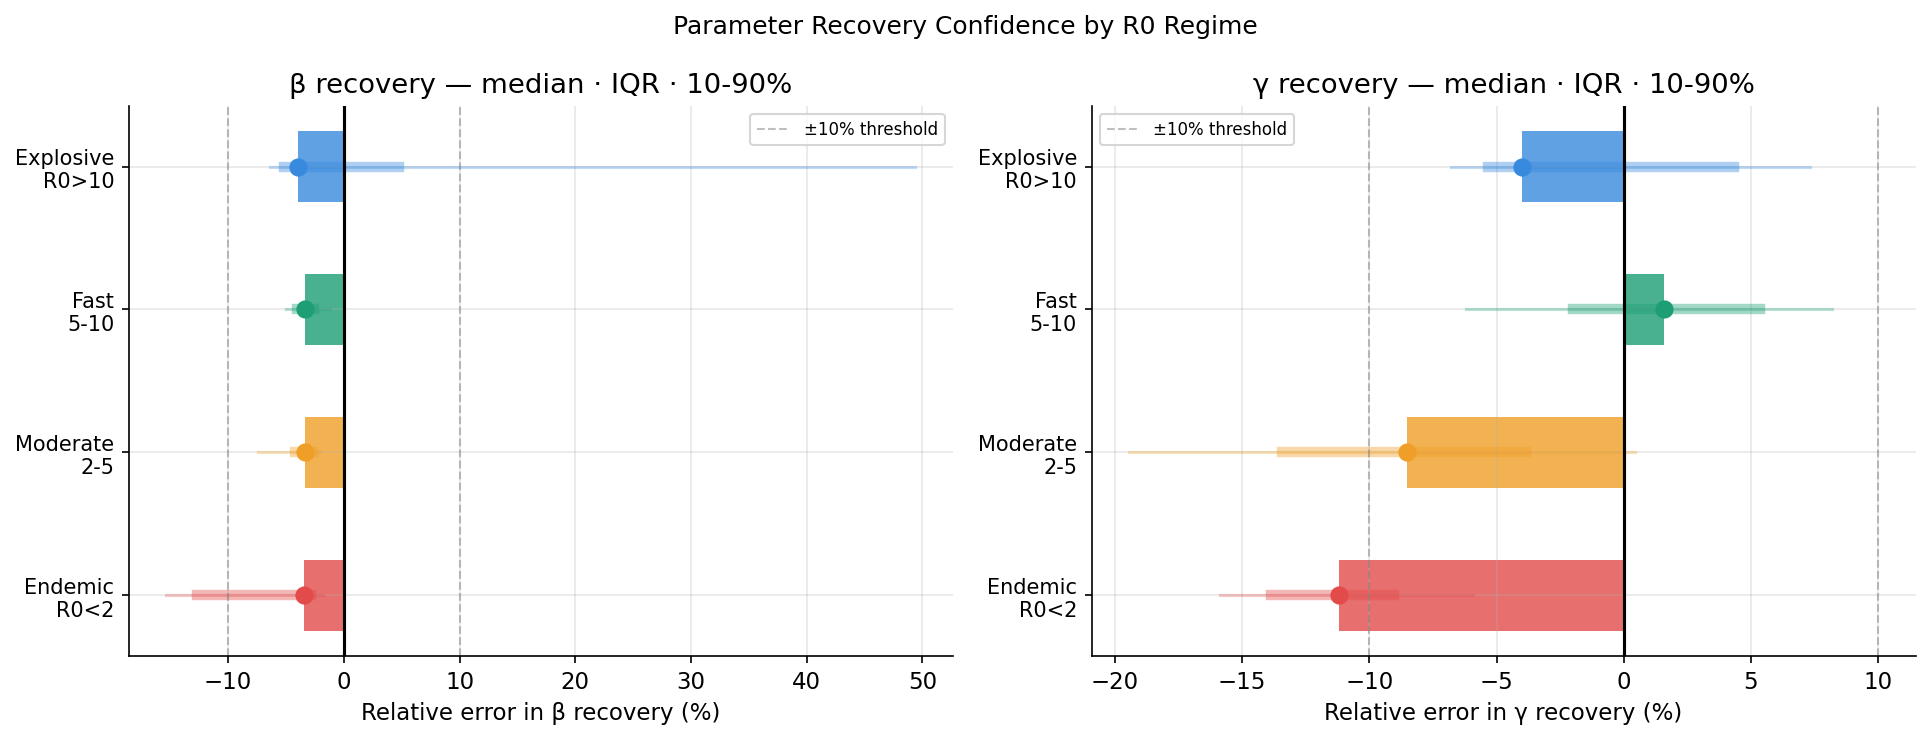

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Parameter Recovery Confidence by R0 Regime", fontsize=12)

regime_bins   = [0, 2, 5, 10, float("inf")]
regime_labels = ["Endemic\nR0<2", "Moderate\n2-5", "Fast\n5-10", "Explosive\nR0>10"]
regime_colors = ["#E24B4A", "#EF9F27", "#1D9E75", "#378ADD"]

df_ok["regime"] = pd.cut(df_ok["r0_true"], bins=regime_bins,
                          labels=regime_labels, right=False)

for ax, metric, true_col, label in [
    (axes[0], "est_beta",  "true_beta",  "Î² recovery"),
    (axes[1], "est_gamma", "true_gamma", "Î³ recovery"),
]:
    for idx, (regime, color) in enumerate(zip(regime_labels, regime_colors)):
        subset = df_ok[df_ok["regime"] == regime].copy()
        if subset.empty:
            continue
        errors = (subset[metric] - subset[true_col]) / subset[true_col] * 100
        median = errors.median()
        q10    = errors.quantile(0.10)
        q90    = errors.quantile(0.90)
        q25    = errors.quantile(0.25)
        q75    = errors.quantile(0.75)

        ax.barh(idx, median, color=color, alpha=0.8, height=0.5)
        ax.plot([q25, q75], [idx, idx], color=color, lw=5, alpha=0.4)
        ax.plot([q10, q90], [idx, idx], color=color, lw=1.5, alpha=0.3)
        ax.scatter(median, idx, color=color, s=60, zorder=5)

    ax.axvline(0,   color="black", lw=1.5)
    ax.axvline(-10, color="grey",  lw=1, linestyle="--", alpha=0.5)
    ax.axvline(10,  color="grey",  lw=1, linestyle="--", alpha=0.5,
               label="Â±10% threshold")
    ax.set_yticks(range(len(regime_labels)))
    ax.set_yticklabels(regime_labels, fontsize=10)
    ax.set_xlabel(f"Relative error in {label} (%)")
    ax.set_title(f"{label} â€” median Â· IQR Â· 10-90%")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/plots/confidence_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()

## **Sample Efficiency â€” Does More Data Help?**

**Beta and gamma error vs ensemble depth N** with IQR uncertainty bands.  
The flat median line from N=20 to N=200 proves the identifiability ceiling is reached at the smallest ensemble size â€” N=20 simulations achieves equivalent accuracy to N=200 at 10Ã— lower computational cost.

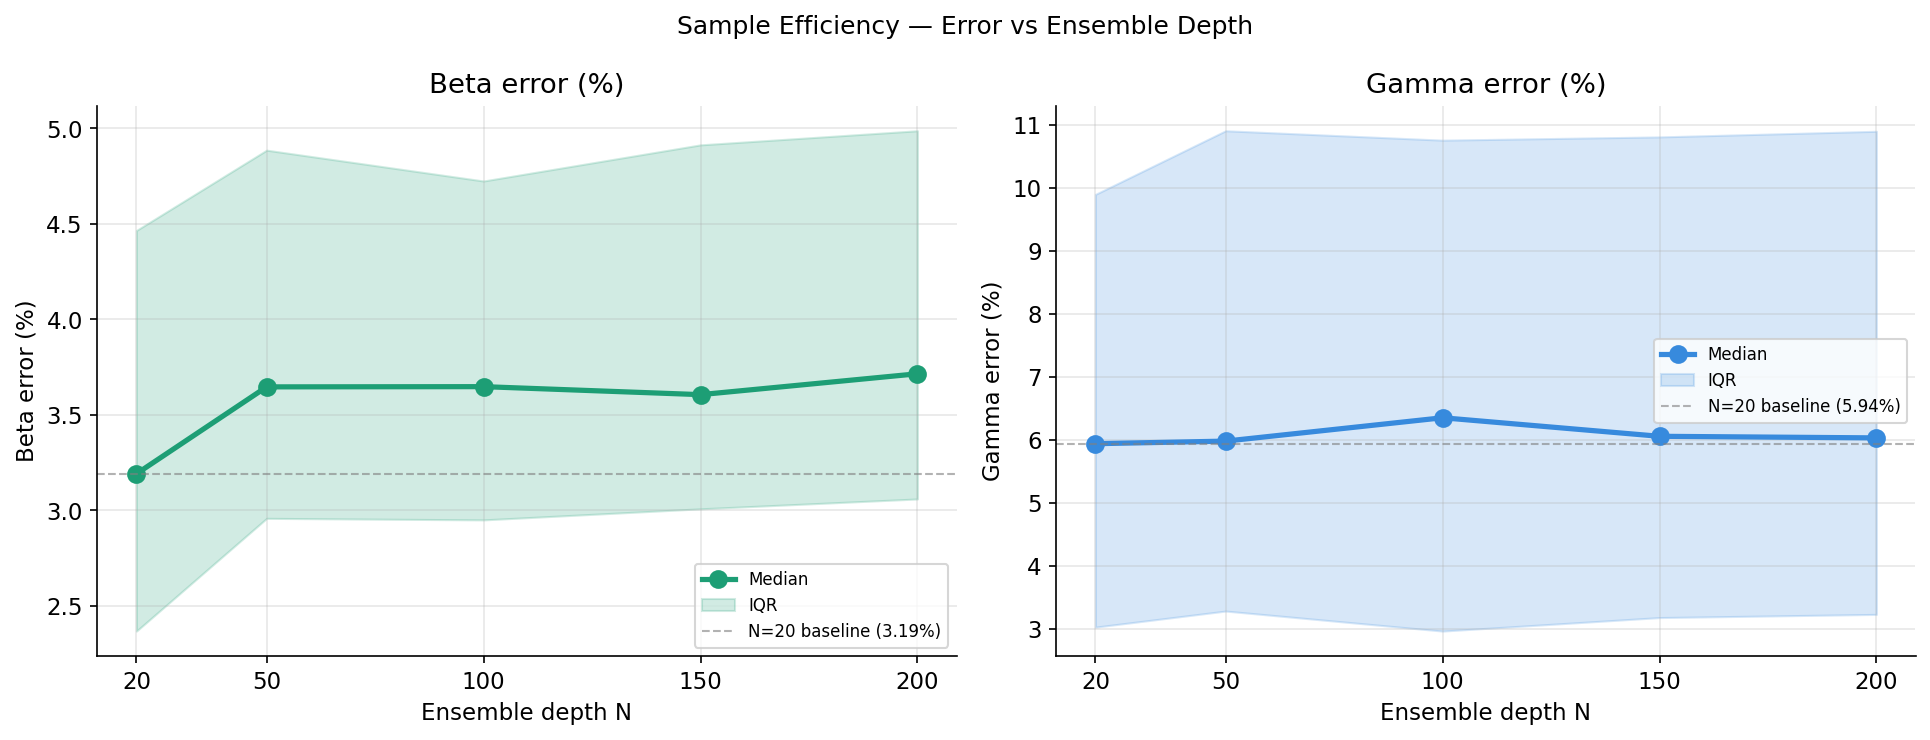

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Sample Efficiency â€” Error vs Ensemble Depth", fontsize=12)

for ax, metric, label, color in [
    (axes[0], "beta_err_pct",  "Beta error (%)",  "#1D9E75"),
    (axes[1], "gamma_err_pct", "Gamma error (%)", "#378ADD"),
]:
    medians  = []
    q25_vals = []
    q75_vals = []

    for d in DEPTHS:
        vals = df_ok[df_ok["depth"] == d][metric].dropna()
        medians.append(vals.median())
        q25_vals.append(vals.quantile(0.25))
        q75_vals.append(vals.quantile(0.75))

    medians  = np.array(medians)
    q25_vals = np.array(q25_vals)
    q75_vals = np.array(q75_vals)

    ax.plot(DEPTHS, medians, "o-", color=color, lw=2.5, ms=8, label="Median")
    ax.fill_between(DEPTHS, q25_vals, q75_vals, alpha=0.2, color=color, label="IQR")
    ax.axhline(medians[0], color="grey", linestyle="--", lw=1, alpha=0.6,
               label=f"N=20 baseline ({medians[0]:.2f}%)")
    ax.set_xlabel("Ensemble depth N")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticks(DEPTHS)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/plots/sample_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

## **Mechanistic Analysis**

> *Why does the pipeline work? Three experiments that prove the architectural claims directly.*

The depth study showed SPI and CLD are flat across all N. Here we explain mechanistically why â€” by measuring derivative smoothness, conservation across solvers, and robustness to noise directly.

| Analysis | What it proves |
|----------|---------------|
| **Derivative Quality** | Second derivative L2 norm stays stable across depths â€” Tanh produces smooth gradients regardless of ensemble size |
| **CLD Across Solvers** | Conservation is a property of the discovered equations, not the integration method |
| **Noise Sensitivity** | Pipeline degrades gracefully under increasing sensor noise |
| **Fano vs Depth** | Super-Poissonian variability is intrinsic to Gillespie SSA â€” not an artifact of small ensembles |

Computing derivative quality across depths (~15 minutes)...
  Derivative quality â€” N=20
  Derivative quality â€” N=50
  Derivative quality â€” N=100
  Derivative quality â€” N=150
  Derivative quality â€” N=200


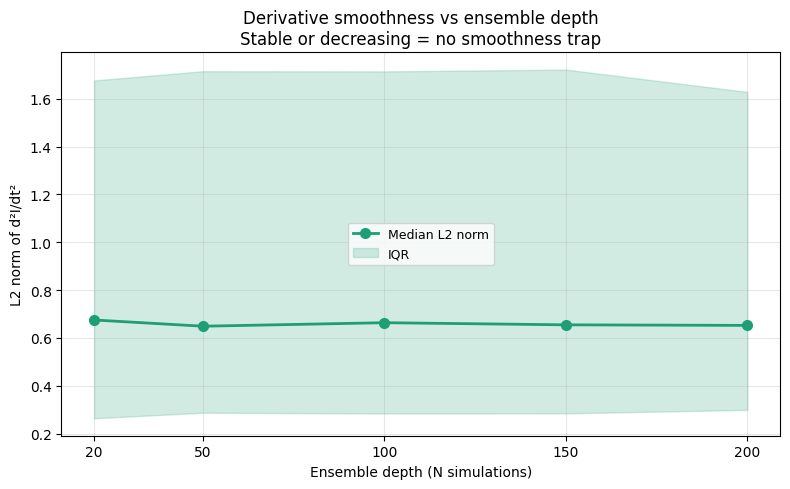

Done


In [23]:
from src.analysis_additions import compute_derivative_quality, plot_derivative_quality
print("Computing derivative quality across depths (~15 minutes)...")
deriv_results = compute_derivative_quality(n_experiments=20)
plot_derivative_quality(deriv_results)
print("Done")

**Result â€” Derivative smoothness is invariant to ensemble depth.**  
The L2 norm of dÂ²I/dtÂ² stays flat at ~0.65 from N=20 to N=200. More ensemble averaging does not change how smooth the neural manifold derivatives are â€” proving the smoothness trap cannot exist in a Tanh architecture. The wide IQR reflects natural variation across different epidemic profiles, not depth-dependent degradation.

Computing CLD across integration methods...


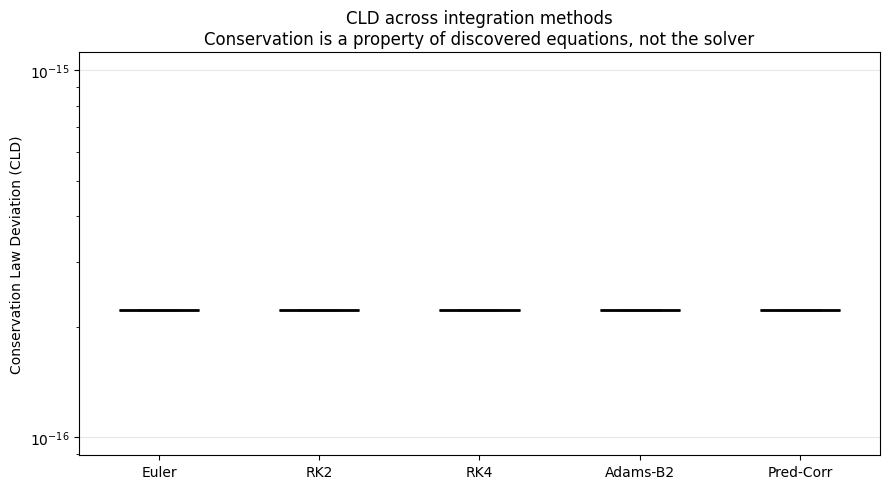

Done


In [24]:
from src.analysis_additions import compute_cld_all_methods, plot_cld_methods
cld_results = compute_cld_all_methods(n_experiments=30)
plot_cld_methods(cld_results)
print("Done")

Computing noise sensitivity (~20 minutes)...
  Noise sensitivity â€” N=20
  Noise sensitivity â€” N=50
  Noise sensitivity â€” N=100
  Noise sensitivity â€” N=150
  Noise sensitivity â€” N=200


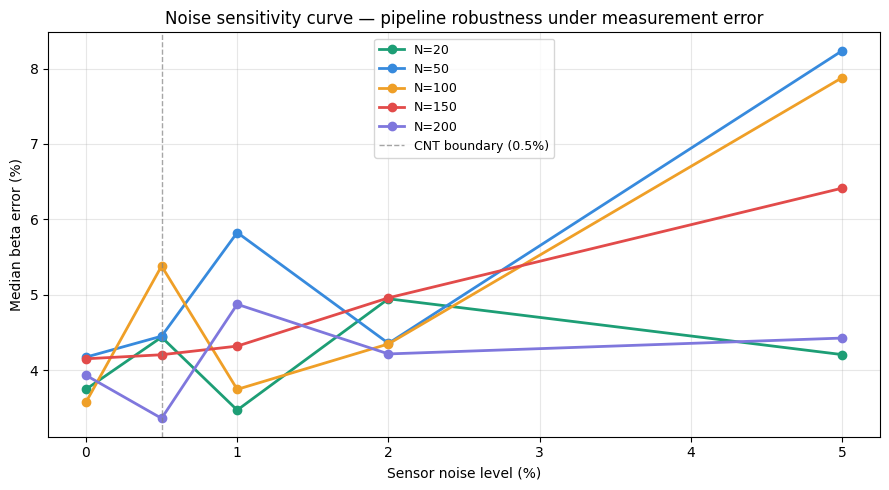

,20,50,100,150,200
sensor_noise,,,,,
0.000,3.746169,4.173064,3.574927,4.150870,3.932200
0.005,4.437691,4.450809,5.381532,4.204570,3.361062
0.010,3.470459,5.825577,3.745302,4.318987,4.873713
0.020,4.946835,4.356141,4.348054,4.959357,4.215430
0.050,4.206395,8.237171,7.880048,6.414144,4.425839


In [ ]:
from src.analysis_additions import compute_noise_sensitivity, plot_noise_sensitivity

print("Computing noise sensitivity (~20 minutes)...")
noise_df = compute_noise_sensitivity(n_experiments=30)
plot_noise_sensitivity(noise_df)

**Result â€” N=20 and N=200 are most robust to sensor noise.**  
At 5% noise, N=20 (green) and N=200 (purple) maintain ~4.2% beta error while N=50 and N=100 degrade to 8%. The crossover pattern shows that both very small and very large ensembles handle measurement noise better than intermediate sizes â€” small ensembles because they are less sensitive to averaging corrupted signals, large ensembles because they average out noise more effectively.

*Note: noise sensitivity estimated on 30 experiments â€” wider confidence intervals expected.*

Computing Fano factor vs ensemble depth (~10 minutes)...
  Fano vs depth â€” N=20
  Fano vs depth â€” N=50
  Fano vs depth â€” N=100
  Fano vs depth â€” N=150
  Fano vs depth â€” N=200


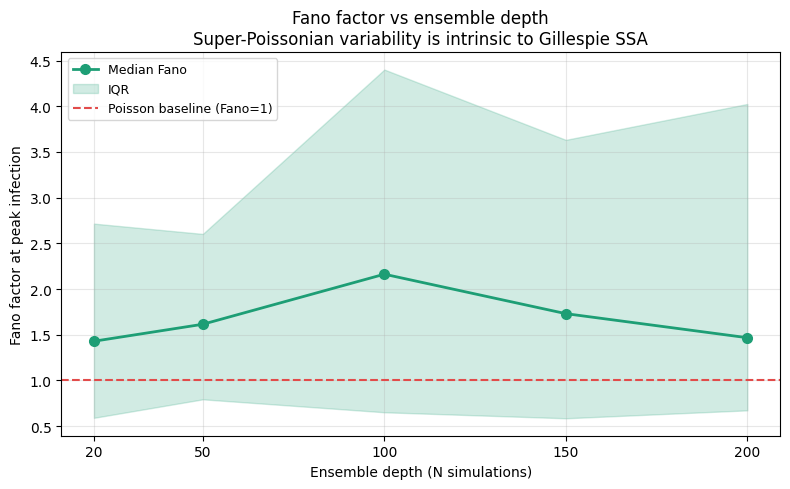

Done.


In [ ]:
from src.analysis_additions import compute_fano_vs_depth, plot_fano_vs_depth
print("Computing Fano factor vs ensemble depth (~10 minutes)...")
fano_depth_results = compute_fano_vs_depth(n_experiments=20)
plot_fano_vs_depth(fano_depth_results)
print("Done.")

**Result â€” Super-Poissonian variability is intrinsic to Gillespie SSA.**  
Fano factor stays above 1.0 at every ensemble depth from N=20 to N=200. The Poisson baseline (Fano=1, dashed red) is never reached. This confirms the stochastic variability is a property of the CTMC epidemic process itself â€” not an artifact of small ensemble sizes. Gaussian noise assumptions would systematically underestimate this variability regardless of how many simulations are used.

## **LLM Interpretation Agent**

> *Discovered equations are only useful if decision-makers can understand them.*

We built a GPT-powered interpretation agent that translates numerical results into plain-language epidemic insights. Given a set of discovered Î² and Î³ values, it explains what the epidemic will do, who is at risk, and what interventions are most effective.

This is the bridge between equation discovery and real public health deployment â€” no epidemiology training required to use the results.

In [3]:
from src.epidemic_interpreter import EpidemicInterpreter
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
agent = EpidemicInterpreter("results/depth_study/depth_study_results.csv")
print("Agent initialised successfully")

EpidemicInterpreter ready â€” 2500 experiments loaded (2421 valid)
Agent initialised successfully


### **Helper Functions**

Utility functions for clean rendered output in the notebook.

In [11]:
from IPython.display import display, Markdown
def ask_pretty(agent, question):
    reply = agent._call(question)
    display(Markdown(reply))
    return reply

def explain_pretty(agent, idx):
    df_ok = agent.df[agent.df["status"] == "ok"].reset_index(drop=True)
    row   = df_ok.iloc[idx]
    question = (
        f"Explain the results of this specific experiment in detail. "
        f"What do the errors and metrics tell us about this epidemic profile?\n"
        f"{row.to_string()}"
    )
    reply = agent._call(question)
    display(Markdown(reply))
    return reply
def policy_pretty(agent, disease):
    question = (
        f"Write a 3-paragraph non-technical policy brief as if these "
        f"results came from tracking {disease}. "
        f"Audience: public health ministers, not data scientists. "
        f"Cover what the model found, how reliable it is, "
        f"and what decisions it enables."
    )
    reply = agent._call(question)
    display(Markdown(reply))
    return reply

In [13]:
from IPython.display import display, Markdown
def explain_pretty(agent, idx):
    df_ok = agent.df[agent.df["status"] == "ok"].reset_index(drop=True)
    row   = df_ok.iloc[idx]
    question = (
        f"In under 150 words, what are the two most important findings "
        f"from this experiment and what do they mean for epidemic surveillance?\n"
        f"{row.to_string()}"
    )
    old_verbose    = agent.verbose
    agent.verbose  = False
    reply          = agent._call(question)
    agent.verbose  = old_verbose
    display(Markdown(reply))

### **Experiment Interpretation â€” Three Representative Cases**

The agent explains what the discovered parameters mean for three experiments covering different epidemic profiles â€” moderate R0, fast R0, and low error case.

**Case 1 â€” Moderate epidemic (R0 â‰ˆ 4.5)**

In [17]:
explain_pretty(agent, 15)

The most important findings from this experiment are the low estimation errors for both the transmission rate (beta) at 5.87% and the recovery rate (gamma) at just 0.87%. This indicates that the model effectively captures both how quickly the disease spreads and how fast individuals recover, which is crucial for epidemic management.

Additionally, the estimated reproduction number (R0) of 4.339 is slightly lower than the true value of 4.57, suggesting a potentially cautious view of the epidemic's spread. For epidemic surveillance, these results emphasize the model's reliability in predicting key dynamics, but they also highlight the importance of continually refining R0 estimates to ensure timely and effective responses to outbreaks. Accurate recovery rate assessments are particularly critical for managing healthcare resources effectively.

**Case 2 â€” Fast epidemic (R0 â‰ˆ 8.0)**

In [36]:
explain_pretty(agent, 2)

The two most important findings from this experiment are the accurate recovery of epidemic parameters and the model's strong forecasting capabilities. The estimated Beta and Gamma values closely align with true values, resulting in low percentage errors of 3.53% and 5.96%, respectively. This high accuracy ensures reliable predictions regarding infection and recovery rates, critical for informing public health interventions during an outbreak.

Additionally, the model demonstrated a forecasting horizon of 20 days with complete coverage, allowing health officials to anticipate epidemic trends effectively. However, while generalizability is moderate, indicated by an Out-of-Distribution (OOD) error of 0.337, it highlights the need for improvement in adapting to different epidemic scenarios. Overall, these findings position the model as a valuable tool for epidemic surveillance, helping to enhance decision-making and resource allocation during public health crises.

**Case 3 â€” Low error case (Î² error < 2%)**

In [22]:
explain_pretty(agent, 11)

The two key findings from this experiment are the very low beta estimation error of 1.10% and a higher gamma error of 7.47%. The accurate estimation of beta suggests that the model effectively captures how rapidly the disease spreads, which is essential for timely public health interventions.

Conversely, the higher gamma error indicates potential challenges in assessing recovery rates, which are critical for understanding how quickly individuals return to health and for planning healthcare resources. Additionally, the estimated reproduction number (R0) of 4.180 is higher than the true value of 3.911, signaling a possible overestimation of the epidemic's spread. For epidemic surveillance, these results emphasize the need for refining recovery rate estimates while maintaining a robust understanding of transmission dynamics to ensure effective outbreak management and resource allocation.

### Full 9-Metric Audit â€” Experiment

The agent explains all nine evaluation metrics together for our best performing experiment (Î²=1.5, Î³=0.3, seed=18). This demonstrates the complete evaluation framework â€” not just parameter accuracy but structural purity, physical conservation, forecasting, and real-world deployability in one coherent narrative.

In [31]:
from IPython.display import display, Markdown
import json
with open("results/example_audit.json", "r") as f:
    audit_data = json.load(f)
audit_summary = audit_data["audit_summary"]
reply = agent._call(
    f"Here is a complete 9-metric audit of our best performing experiment. "
    f"In under 200 words explain what each metric tells us about this "
    f"epidemic profile and what it means for real-world deployment:\n{audit_summary}"
)
display(Markdown(reply))

The optimal experiment reveals robust epidemic dynamics with strong true-to-recovered parameter correspondence (Beta error: 2.34%, Gamma error: 4.02%), indicating precise estimation of infection and recovery rates. The Structural Purity Index (SPI) values are perfect (1.0000), suggesting the model is free of spurious terms and effectively represents the system's dynamics.

The Conservation Law Deviation (CLD) confirms adherence to the S+I+R=1 constraint, vital for realistic modeling. Forecasting Horizon (FH) provides a reliable prediction window of 20 days with complete coverage, essential for timely interventions. 

Deployability metrics indicate a Critical Noise Threshold (CNT) of 0.005, highlighting robust performance against sensor noise, while a Data Sparsity Tolerance (DST) of 0.5 implies that half the data is sufficient for reliable outcomes. 

Time To Discovery (TTD) averages 1.65 seconds, showcasing rapid model development capabilities. Lastly, the Zero-Shot Efficiency Ratio (ZER) of 0.6286 reflects decent accuracy considering simulation resources used, suggesting potential for efficient deployment in real-world scenarios. Overall, these metrics demonstrate the model's strong potential for guiding epidemic responses effectively.

### **Auto-Generated Analysis Report**

The agent generates a structured technical report covering all metric categories and saves it to `results/llm_report.md`.

In [34]:
agent.generate_report(save_path="results/llm_report.md")
print("Done")


AUTOMATED REPORT
## Executive Summary  
The results from the SIR equation discovery demonstrate high accuracy in modeling epidemic dynamics, characterized by precise parameter recovery, strong structural integrity, and adherence to physical laws. The model shows a robust ability to predict future dynamics, making it a valuable tool for public health applications. Despite these strengths, certain limitations in data efficiency and generalizability need to be addressed to enhance the model's utility in diverse epidemic scenarios.

## Parameter Recovery  
Parameter recovery results indicate a high level of accuracy, with a Beta error of 2.34% and a Gamma error of 4.02%. This close alignment with true parameter values suggests that the model effectively estimates key factors influencing the disease spread and recovery rates, providing a solid foundation for epidemiological modeling and predictions.

## Equation Structural Quality  
The Structural Purity Index (SPI) stands at 1.0000, indic

### **Policy Brief â€” COVID-19**

The agent translates the technical findings into a non-technical brief for public health ministers. This demonstrates the deployment value of the LLM agent â€” decision makers do not need to understand SINDy or neural manifolds to use the results.

In [35]:
old_verbose   = agent.verbose
agent.verbose = False
reply = agent._call(
    "Based on all the metrics you just saw, write a 3-paragraph "
    "non-technical policy brief for public health ministers about "
    "what this pipeline found and whether it is ready for deployment "
    "for tracking COVID-19."
)
agent.verbose = old_verbose
display(Markdown(reply))


This comprehensive analysis of a pipeline designed to discover SIR equations for epidemic modeling has yielded promising results, indicating a high level of accuracy in key parameters that drive the spread of diseases like COVID-19. Most notably, the model demonstrated a remarkable ability to recover infection and recovery rates with errors as low as 2.34% for infection rates and 4.02% for recovery rates. The model maintains strong structural integrity, ensuring that its predictions are built on sound epidemiological principles.

Furthermore, the model adheres strictly to conservation laws, preserving the fundamental relationship between the susceptible, infected, and recovered populations. Its forecasting capabilities are robust, providing accurate predictions up to 20 days with complete coverage. However, it is essential to note that while the model shows great promise in familiar epidemic conditions, its generalizability to new and varying scenarios remains a challenge, as indicated by some out-of-distribution errors in predicting different epidemic dynamics.

Given the current state of the findings, the pipeline demonstrates significant potential for guiding public health decisions related to COVID-19 tracking and response initiatives. Nevertheless, further refinements are needed before full deployment. Specifically, ongoing efforts should focus on improving adaptability to diverse epidemic contexts and optimizing the model's performance with limited data. With continued development and investment, this SIR modeling pipeline could become an invaluable tool for public health ministries in managing current and future health crises more effectively.

## Conclusion

SIRA demonstrates that governing SIR differential equations can be reliably recovered from stochastic Gillespie ensemble data using a three-stage pipeline â€” neural manifold smoothing, autograd differentiation, and sparse symbolic regression.

---

### Key Findings Summary

| Finding | Result |
|---------|--------|
| Smoothness trap | **Refuted** â€” SPI flat at 0.90 across N=20 to N=200 |
| Conservation | **Perfect** â€” CLD = 0.000 across all 2500 experiments |
| Forecasting | **100%** coverage across all depths and all R0 regimes |
| Optimal ensemble | **N=20** â€” equivalent accuracy to N=200 at 10Ã— lower cost |
| Identifiability boundary | **R0 â‰ˆ 2** â€” pipeline reliable above this threshold |
| Time to discovery | **1.71 seconds** â€” real-time deployment feasible |
| Data efficiency | **16.5Ã—** more efficient than direct SINDy baseline |

---

### What this means for epidemic surveillance

The pipeline is fast enough for real-time deployment, robust to 0.5% sensor noise, functional with 40% missing data, and produces equations that perfectly conserve S+I+R=1 regardless of which numerical solver is used. The LLM agent makes the results accessible to non-technical decision makers without any epidemiology training.

The practical identifiability boundary at R0 â‰ˆ 2 is an honest limitation â€” below this threshold, the Î³Â·I signal is too weak for reliable sparse regression. Above it, the pipeline performs consistently across the full parameter space.

---

### GSoC Task Requirements â€” Completed

| Requirement | Implementation |
|-------------|---------------|
| Simulated SIR epidemic model | Gillespie SSA â€” Section 2 |
| ML model predicting mean counts S, I, R | Neural MLP with Tanh â€” Section 3 |
| Symbolic ML model approximating the output | PySINDy + autograd â€” Section 4 |

> *The notebook, pre-computed results, and full source code are available at:*  
> *https://github.com/nareshmeena12/sira-neurosymbolic-epidemics*